In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mansurislam/teenage-data/Autism-Adolescent-Data.arff
/kaggle/input/datasets/mansurislam/adult-dataset/Autism-Adult-Data.arff
/kaggle/input/datasets/mansurislam/child-dataset/Autism-Child-Data.arff


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
from scipy.io import arff
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import RandomizedSearchCV

In [3]:
# read the csv data to a pandas dataframe

data, meta = arff.loadarff("/kaggle/input/datasets/mansurislam/child-dataset/Autism-Child-Data.arff")
df = pd.DataFrame(data)

print(df.shape)
print(df.head())

(292, 21)
  A1_Score A2_Score A3_Score A4_Score A5_Score A6_Score A7_Score A8_Score  \
0     b'1'     b'1'     b'0'     b'0'     b'1'     b'1'     b'0'     b'1'   
1     b'1'     b'1'     b'0'     b'0'     b'1'     b'1'     b'0'     b'1'   
2     b'1'     b'1'     b'0'     b'0'     b'0'     b'1'     b'1'     b'1'   
3     b'0'     b'1'     b'0'     b'0'     b'1'     b'1'     b'0'     b'0'   
4     b'1'     b'1'     b'1'     b'1'     b'1'     b'1'     b'1'     b'1'   

  A9_Score A10_Score  ...  gender           ethnicity jundice austim  \
0     b'0'      b'0'  ...    b'm'           b'Others'   b'no'  b'no'   
1     b'0'      b'0'  ...    b'm'  b'Middle Eastern '   b'no'  b'no'   
2     b'0'      b'0'  ...    b'm'                b'?'   b'no'  b'no'   
3     b'0'      b'1'  ...    b'f'                b'?'  b'yes'  b'no'   
4     b'1'      b'1'  ...    b'm'           b'Others'  b'yes'  b'no'   

      contry_of_res used_app_before result       age_desc   relation Class/ASD  
0         b'J

In [4]:
# read the csv data to a pandas dataframe

data, meta = arff.loadarff("/kaggle/input/datasets/mansurislam/teenage-data/Autism-Adolescent-Data.arff")
df1 = pd.DataFrame(data)

print(df1.shape)
print(df1.head())

(104, 21)
  A1_Score A2_Score A3_Score A4_Score A5_Score A6_Score A7_Score A8_Score  \
0     b'0'     b'0'     b'0'     b'1'     b'1'     b'1'     b'1'     b'1'   
1     b'0'     b'0'     b'0'     b'0'     b'0'     b'0'     b'0'     b'0'   
2     b'0'     b'0'     b'0'     b'0'     b'0'     b'0'     b'0'     b'0'   
3     b'0'     b'1'     b'1'     b'1'     b'1'     b'1'     b'0'     b'1'   
4     b'1'     b'1'     b'1'     b'1'     b'1'     b'1'     b'1'     b'0'   

  A9_Score A10_Score  ...  gender          ethnicity jundice  austim  \
0     b'1'      b'0'  ...    b'm'        b'Hispanic'  b'yes'  b'yes'   
1     b'1'      b'1'  ...    b'm'           b'Black'   b'no'   b'no'   
2     b'1'      b'1'  ...    b'f'               b'?'   b'no'   b'no'   
3     b'1'      b'0'  ...    b'f'  b'White-European'   b'no'   b'no'   
4     b'0'      b'0'  ...    b'f'               b'?'   b'no'   b'no'   

       contry_of_res used_app_before result        age_desc     relation  \
0         b'Austri

In [5]:
# read the csv data to a pandas dataframe

data, meta = arff.loadarff("/kaggle/input/datasets/mansurislam/adult-dataset/Autism-Adult-Data.arff")
df2 = pd.DataFrame(data)

print(df2.shape)
print(df2.head())

(704, 21)
  A1_Score A2_Score A3_Score A4_Score A5_Score A6_Score A7_Score A8_Score  \
0     b'1'     b'1'     b'1'     b'1'     b'0'     b'0'     b'1'     b'1'   
1     b'1'     b'1'     b'0'     b'1'     b'0'     b'0'     b'0'     b'1'   
2     b'1'     b'1'     b'0'     b'1'     b'1'     b'0'     b'1'     b'1'   
3     b'1'     b'1'     b'0'     b'1'     b'0'     b'0'     b'1'     b'1'   
4     b'1'     b'0'     b'0'     b'0'     b'0'     b'0'     b'0'     b'1'   

  A9_Score A10_Score  ...  gender          ethnicity jundice  austim  \
0     b'0'      b'0'  ...    b'f'  b'White-European'   b'no'   b'no'   
1     b'0'      b'1'  ...    b'm'          b'Latino'   b'no'  b'yes'   
2     b'1'      b'1'  ...    b'm'          b'Latino'  b'yes'  b'yes'   
3     b'0'      b'1'  ...    b'f'  b'White-European'   b'no'  b'yes'   
4     b'0'      b'0'  ...    b'f'               b'?'   b'no'   b'no'   

      contry_of_res used_app_before result        age_desc   relation  \
0  b'United States'  

In [6]:
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].str.decode("utf-8")

In [7]:
print(df.shape)
df.head()

(292, 21)


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,0,1,1,0,1,0,0,...,m,Others,no,no,Jordan,no,5.0,4-11 years,Parent,NO
1,1,1,0,0,1,1,0,1,0,0,...,m,Middle Eastern,no,no,Jordan,no,5.0,4-11 years,Parent,NO
2,1,1,0,0,0,1,1,1,0,0,...,m,?,no,no,Jordan,yes,5.0,4-11 years,?,NO
3,0,1,0,0,1,1,0,0,0,1,...,f,?,yes,no,Jordan,no,4.0,4-11 years,?,NO
4,1,1,1,1,1,1,1,1,1,1,...,m,Others,yes,no,United States,no,10.0,4-11 years,Parent,YES


In [8]:
for col in df1.columns:
    if df1[col].dtype == object:
        df1[col] = df1[col].str.decode("utf-8")

In [9]:
print(df1.shape)
df1.head()

(104, 21)


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,0,0,0,1,1,1,1,1,1,0,...,m,Hispanic,yes,yes,Austria,no,6.0,12-16 years,Parent,NO
1,0,0,0,0,0,0,0,0,1,1,...,m,Black,no,no,Austria,no,2.0,12-16 years,Relative,NO
2,0,0,0,0,0,0,0,0,1,1,...,f,?,no,no,AmericanSamoa,no,2.0,12-16 years,?,NO
3,0,1,1,1,1,1,0,1,1,0,...,f,White-European,no,no,United Kingdom,no,7.0,12-16 years,Self,YES
4,1,1,1,1,1,1,1,0,0,0,...,f,?,no,no,Albania,no,7.0,12-16 years,?,YES


In [10]:
for col in df2.columns:
    if df2[col].dtype == object:
        df2[col] = df2[col].str.decode("utf-8")

In [11]:
print(df2.shape)
df2.head()


(704, 21)


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,United States,no,6.0,18 and more,Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5.0,18 and more,Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8.0,18 and more,Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,United States,no,6.0,18 and more,Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2.0,18 and more,?,NO


In [12]:
import pandas as pd

# Combine all three datasets
df = pd.concat(
    [df, df1, df2],
    ignore_index=True
)

# Check the shape
print("Combined Dataset Shape:",df.shape)

# Preview
df.head()

Combined Dataset Shape: (1100, 21)


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,0,1,1,0,1,0,0,...,m,Others,no,no,Jordan,no,5.0,4-11 years,Parent,NO
1,1,1,0,0,1,1,0,1,0,0,...,m,Middle Eastern,no,no,Jordan,no,5.0,4-11 years,Parent,NO
2,1,1,0,0,0,1,1,1,0,0,...,m,?,no,no,Jordan,yes,5.0,4-11 years,?,NO
3,0,1,0,0,1,1,0,0,0,1,...,f,?,yes,no,Jordan,no,4.0,4-11 years,?,NO
4,1,1,1,1,1,1,1,1,1,1,...,m,Others,yes,no,United States,no,10.0,4-11 years,Parent,YES


In [13]:
print(df.shape)
print(df.info())
df.head()

(1100, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A1_Score         1100 non-null   object 
 1   A2_Score         1100 non-null   object 
 2   A3_Score         1100 non-null   object 
 3   A4_Score         1100 non-null   object 
 4   A5_Score         1100 non-null   object 
 5   A6_Score         1100 non-null   object 
 6   A7_Score         1100 non-null   object 
 7   A8_Score         1100 non-null   object 
 8   A9_Score         1100 non-null   object 
 9   A10_Score        1100 non-null   object 
 10  age              1094 non-null   float64
 11  gender           1100 non-null   object 
 12  ethnicity        1100 non-null   object 
 13  jundice          1100 non-null   object 
 14  austim           1100 non-null   object 
 15  contry_of_res    1100 non-null   object 
 16  used_app_before  1100 non-null   object 
 17  res

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,0,1,1,0,1,0,0,...,m,Others,no,no,Jordan,no,5.0,4-11 years,Parent,NO
1,1,1,0,0,1,1,0,1,0,0,...,m,Middle Eastern,no,no,Jordan,no,5.0,4-11 years,Parent,NO
2,1,1,0,0,0,1,1,1,0,0,...,m,?,no,no,Jordan,yes,5.0,4-11 years,?,NO
3,0,1,0,0,1,1,0,0,0,1,...,f,?,yes,no,Jordan,no,4.0,4-11 years,?,NO
4,1,1,1,1,1,1,1,1,1,1,...,m,Others,yes,no,United States,no,10.0,4-11 years,Parent,YES


In [14]:
# display all columns of a dataframe
pd.set_option('display.max_columns', None)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A1_Score         1100 non-null   object 
 1   A2_Score         1100 non-null   object 
 2   A3_Score         1100 non-null   object 
 3   A4_Score         1100 non-null   object 
 4   A5_Score         1100 non-null   object 
 5   A6_Score         1100 non-null   object 
 6   A7_Score         1100 non-null   object 
 7   A8_Score         1100 non-null   object 
 8   A9_Score         1100 non-null   object 
 9   A10_Score        1100 non-null   object 
 10  age              1094 non-null   float64
 11  gender           1100 non-null   object 
 12  ethnicity        1100 non-null   object 
 13  jundice          1100 non-null   object 
 14  austim           1100 non-null   object 
 15  contry_of_res    1100 non-null   object 
 16  used_app_before  1100 non-null   object 
 17  result        

In [15]:
for col in df.columns:
  numerical_features = ["ID", "age", "result"]
  if col not in numerical_features:
    print(col, df[col].unique())
   

A1_Score ['1' '0']
A2_Score ['1' '0']
A3_Score ['0' '1']
A4_Score ['0' '1']
A5_Score ['1' '0']
A6_Score ['1' '0']
A7_Score ['0' '1']
A8_Score ['1' '0']
A9_Score ['0' '1']
A10_Score ['0' '1']
gender ['m' 'f']
ethnicity ['Others' 'Middle Eastern ' '?' 'White-European' 'Black' 'South Asian'
 'Asian' 'Pasifika' 'Hispanic' 'Turkish' 'Latino' 'others']
jundice ['no' 'yes']
austim ['no' 'yes']
contry_of_res ['Jordan' 'United States' 'Egypt' 'United Kingdom' 'Bahrain' 'Austria'
 'Kuwait' 'United Arab Emirates' 'Europe' 'Malta' 'Bulgaria'
 'South Africa' 'India' 'Afghanistan' 'Georgia' 'New Zealand' 'Syria'
 'Iraq' 'Australia' 'Saudi Arabia' 'Armenia' 'Turkey' 'Pakistan' 'Canada'
 'Oman' 'Brazil' 'South Korea' 'Costa Rica' 'Sweden' 'Philippines'
 'Malaysia' 'Argentina' 'Japan' 'Bangladesh' 'Qatar' 'Ireland' 'Romania'
 'Netherlands' 'Lebanon' 'Germany' 'Latvia' 'Russia' 'Italy' 'China'
 'Nigeria' 'U.S. Outlying Islands' 'Nepal' 'Mexico' 'Isle of Man' 'Libya'
 'Ghana' 'Bhutan' 'AmericanSamoa' 'Al

**Class Distribution**

/tmp/ipykernel_16/494053889.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


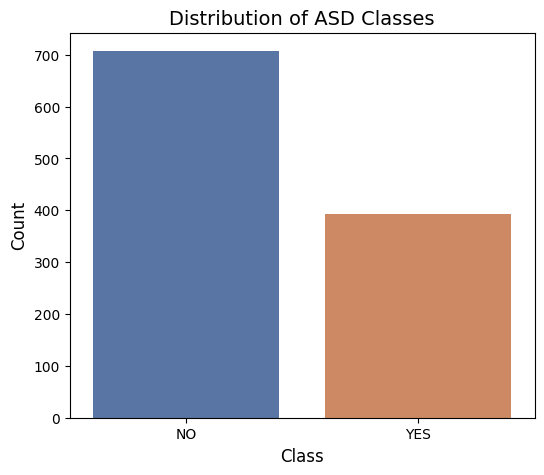

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Class/ASD",
    palette=["#4C72B0", "#DD8452"]   # Blue and Orange
)

plt.title("Distribution of ASD Classes", fontsize=14)
plt.xlabel("Class", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()

Missing Value Heatmap

# **Handle MIssing Vlue**

In [17]:
import numpy as np

df.replace("?", np.nan, inplace=True)

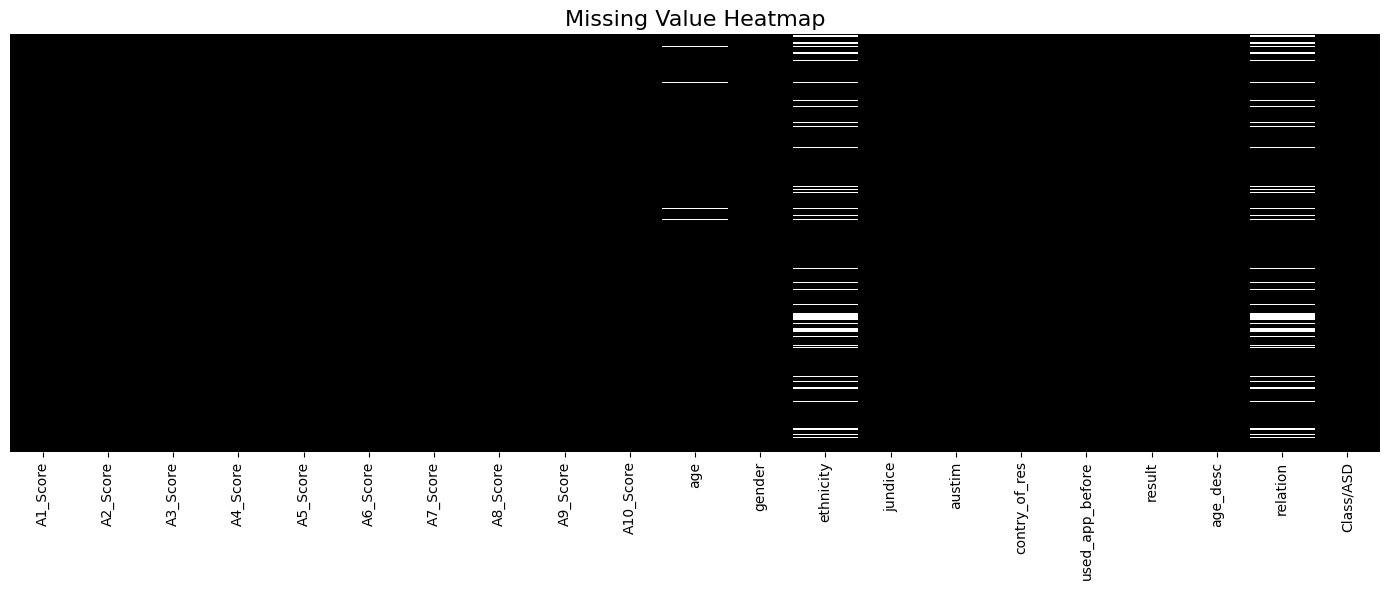

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap=sns.color_palette(["#000000", "#FFFFFF"], as_cmap=True)
)

plt.title("Missing Value Heatmap", fontsize=16)
plt.tight_layout()

plt.show()

In [19]:
df.isnull().sum()

A1_Score             0
A2_Score             0
A3_Score             0
A4_Score             0
A5_Score             0
A6_Score             0
A7_Score             0
A8_Score             0
A9_Score             0
A10_Score            0
age                  6
gender               0
ethnicity          144
jundice              0
austim               0
contry_of_res        0
used_app_before      0
result               0
age_desc             0
relation           144
Class/ASD            0
dtype: int64

<Axes: >

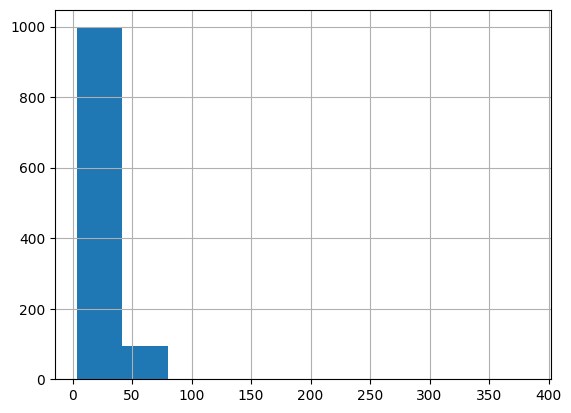

In [20]:
df["age"].hist()

In [21]:
df["age"] = df["age"].fillna(round(df["age"].mean())).astype(int)


In [22]:
df["ethnicity"] = df["ethnicity"].fillna("Others")
df["relation"] = df["relation"].fillna("Others")

In [23]:
df.isnull().sum()

A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethnicity          0
jundice            0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64

In [24]:


for col in df.columns:
  numerical_features = ["ID", "age", "result"]
  if col not in numerical_features:
    print(col, df[col].unique())

A1_Score ['1' '0']
A2_Score ['1' '0']
A3_Score ['0' '1']
A4_Score ['0' '1']
A5_Score ['1' '0']
A6_Score ['1' '0']
A7_Score ['0' '1']
A8_Score ['1' '0']
A9_Score ['0' '1']
A10_Score ['0' '1']
gender ['m' 'f']
ethnicity ['Others' 'Middle Eastern ' 'White-European' 'Black' 'South Asian' 'Asian'
 'Pasifika' 'Hispanic' 'Turkish' 'Latino' 'others']
jundice ['no' 'yes']
austim ['no' 'yes']
contry_of_res ['Jordan' 'United States' 'Egypt' 'United Kingdom' 'Bahrain' 'Austria'
 'Kuwait' 'United Arab Emirates' 'Europe' 'Malta' 'Bulgaria'
 'South Africa' 'India' 'Afghanistan' 'Georgia' 'New Zealand' 'Syria'
 'Iraq' 'Australia' 'Saudi Arabia' 'Armenia' 'Turkey' 'Pakistan' 'Canada'
 'Oman' 'Brazil' 'South Korea' 'Costa Rica' 'Sweden' 'Philippines'
 'Malaysia' 'Argentina' 'Japan' 'Bangladesh' 'Qatar' 'Ireland' 'Romania'
 'Netherlands' 'Lebanon' 'Germany' 'Latvia' 'Russia' 'Italy' 'China'
 'Nigeria' 'U.S. Outlying Islands' 'Nepal' 'Mexico' 'Isle of Man' 'Libya'
 'Ghana' 'Bhutan' 'AmericanSamoa' 'Albani

In [25]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 8


Drop duplicate Row 
Also drop age_dec

In [26]:
df = df.drop_duplicates()
# Remove non-informative and leakage columns
df.drop(columns=["age_desc", "result"], inplace=True)

In [27]:
print(df[["A1_Score", "A2_Score"]].dtypes)

A1_Score    object
A2_Score    object
dtype: object


In [28]:
score_cols = [f"A{i}_Score" for i in range(1, 11)]

df[score_cols] = df[score_cols].astype(int)

**One-Hot Encoding**

In [29]:
# Columns with multiple categories
multi_class_cols = [
    "ethnicity",
    "contry_of_res",
    "relation"
]

# Apply One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=multi_class_cols,
    drop_first=True,
    dtype=int
)

In [30]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,jundice,austim,used_app_before,Class/ASD,ethnicity_Black,ethnicity_Hispanic,ethnicity_Latino,ethnicity_Middle Eastern,ethnicity_Others,ethnicity_Pasifika,ethnicity_South Asian,ethnicity_Turkish,ethnicity_White-European,ethnicity_others,contry_of_res_Albania,contry_of_res_AmericanSamoa,contry_of_res_Angola,contry_of_res_Anguilla,contry_of_res_Argentina,contry_of_res_Armenia,contry_of_res_Aruba,contry_of_res_Australia,contry_of_res_Austria,contry_of_res_Azerbaijan,contry_of_res_Bahamas,contry_of_res_Bahrain,contry_of_res_Bangladesh,contry_of_res_Belgium,contry_of_res_Bhutan,contry_of_res_Bolivia,contry_of_res_Brazil,contry_of_res_Bulgaria,contry_of_res_Burundi,contry_of_res_Canada,contry_of_res_Chile,contry_of_res_China,contry_of_res_Comoros,contry_of_res_Costa Rica,contry_of_res_Croatia,contry_of_res_Cyprus,contry_of_res_Czech Republic,contry_of_res_Ecuador,contry_of_res_Egypt,contry_of_res_Ethiopia,contry_of_res_Europe,contry_of_res_Finland,contry_of_res_France,contry_of_res_Georgia,contry_of_res_Germany,contry_of_res_Ghana,contry_of_res_Greenland,contry_of_res_Hong Kong,contry_of_res_Iceland,contry_of_res_India,contry_of_res_Indonesia,contry_of_res_Iran,contry_of_res_Iraq,contry_of_res_Ireland,contry_of_res_Isle of Man,contry_of_res_Italy,contry_of_res_Japan,contry_of_res_Jordan,contry_of_res_Kazakhstan,contry_of_res_Kuwait,contry_of_res_Latvia,contry_of_res_Lebanon,contry_of_res_Libya,contry_of_res_Malaysia,contry_of_res_Malta,contry_of_res_Mexico,contry_of_res_Nepal,contry_of_res_Netherlands,contry_of_res_New Zealand,contry_of_res_Nicaragua,contry_of_res_Niger,contry_of_res_Nigeria,contry_of_res_Norway,contry_of_res_Oman,contry_of_res_Pakistan,contry_of_res_Philippines,contry_of_res_Portugal,contry_of_res_Qatar,contry_of_res_Romania,contry_of_res_Russia,contry_of_res_Saudi Arabia,contry_of_res_Serbia,contry_of_res_Sierra Leone,contry_of_res_South Africa,contry_of_res_South Korea,contry_of_res_Spain,contry_of_res_Sri Lanka,contry_of_res_Sweden,contry_of_res_Syria,contry_of_res_Tonga,contry_of_res_Turkey,contry_of_res_U.S. Outlying Islands,contry_of_res_Ukraine,contry_of_res_United Arab Emirates,contry_of_res_United Kingdom,contry_of_res_United States,contry_of_res_Uruguay,contry_of_res_Viet Nam,relation_Others,relation_Parent,relation_Relative,relation_Self,relation_self
0,1,1,0,0,1,1,0,1,0,0,6,m,no,no,no,NO,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,1,1,0,0,1,1,0,1,0,0,6,m,no,no,no,NO,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,1,1,0,0,0,1,1,1,0,0,6,m,no,no,yes,NO,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,1,0,0,1,1,0,0,0,1,5,f,yes,no,no,NO,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,1,1,1,1,1,1,1,1,1,1,5,m,yes,no,no,YES,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0


In [31]:
print(df.shape)
print(df.columns.tolist())

(1092, 119)
['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'jundice', 'austim', 'used_app_before', 'Class/ASD', 'ethnicity_Black', 'ethnicity_Hispanic', 'ethnicity_Latino', 'ethnicity_Middle Eastern ', 'ethnicity_Others', 'ethnicity_Pasifika', 'ethnicity_South Asian', 'ethnicity_Turkish', 'ethnicity_White-European', 'ethnicity_others', 'contry_of_res_Albania', 'contry_of_res_AmericanSamoa', 'contry_of_res_Angola', 'contry_of_res_Anguilla', 'contry_of_res_Argentina', 'contry_of_res_Armenia', 'contry_of_res_Aruba', 'contry_of_res_Australia', 'contry_of_res_Austria', 'contry_of_res_Azerbaijan', 'contry_of_res_Bahamas', 'contry_of_res_Bahrain', 'contry_of_res_Bangladesh', 'contry_of_res_Belgium', 'contry_of_res_Bhutan', 'contry_of_res_Bolivia', 'contry_of_res_Brazil', 'contry_of_res_Bulgaria', 'contry_of_res_Burundi', 'contry_of_res_Canada', 'contry_of_res_Chile', 'contry_of_res_China', 'contry_of_r

**Label Encoding**

In [32]:
le = LabelEncoder()
# define the binary columns:
binary_cols = [
    "gender",
    "jundice",
    "austim",
    "used_app_before",
    "Class/ASD"
]
# Apply Label Encoding:
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [33]:
for col in binary_cols:
    print(col, df[col].unique())

gender [1 0]
jundice [0 1]
austim [0 1]
used_app_before [0 1]
Class/ASD [0 1]


# **Train-Test Split**

**Separate Features and Target**

In [34]:
# Features (input variables)
X = df.drop("Class/ASD", axis=1)

# Target (output variable)
y = df["Class/ASD"]

In [35]:
print(X.shape)
print(y.shape)

(1092, 118)
(1092,)


**Split the Dataset**

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [37]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (764, 118)
X_test : (328, 118)
y_train: (764,)
y_test : (328,)


**Min-Max Scaling**

In [38]:
from sklearn.preprocessing import MinMaxScaler

# Create scaler
scaler = MinMaxScaler()

# Columns to scale
numeric_cols = ["age"]

# Fit on training data and transform it
X_train[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

# Transform test data using the same scaler
X_test[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

# Verify scaling
print(X_train[numeric_cols].describe())

              age
count  764.000000
mean     0.294197
std      0.213698
min      0.000000
25%      0.116667
50%      0.283333
75%      0.433333
max      1.000000


**Chi-Square**

In [39]:


# Select top 20 features
selector = SelectKBest(score_func=chi2, k=20)

# Fit on training data
X_train_selected = selector.fit_transform(X_train, y_train)

# Transform test data
X_test_selected = selector.transform(X_test)

# Feature scores
feature_scores = pd.DataFrame({
    "Feature": X_train.columns,
    "Chi2 Score": selector.scores_
})

feature_scores = feature_scores.sort_values(
    by="Chi2 Score",
    ascending=False
)

print(feature_scores)

# Selected features
selected_features = X_train.columns[selector.get_support()]

print("\nSelected Features:")
print(selected_features)

                       Feature  Chi2 Score
8                     A9_Score  142.012649
5                     A6_Score  125.600615
3                     A4_Score   83.924504
4                     A5_Score   81.515789
2                     A3_Score   75.055875
..                         ...         ...
63       contry_of_res_Iceland         NaN
79         contry_of_res_Malta         NaN
85         contry_of_res_Niger         NaN
86       contry_of_res_Nigeria         NaN
97  contry_of_res_Sierra Leone         NaN

[118 rows x 2 columns]

Selected Features:
Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score',
       'ethnicity_Middle Eastern ', 'ethnicity_White-European',
       'contry_of_res_India', 'contry_of_res_Jordan',
       'contry_of_res_South Africa', 'contry_of_res_United Arab Emirates',
       'contry_of_res_United Kingdom', 'contry_of_res_United States',
       'relation_Others', 'relation_Parent

In [40]:
selector = SelectKBest(score_func=chi2, k="all")
selector.fit(X_train, y_train)

feature_scores = pd.DataFrame({
    "Feature": X_train.columns,
    "Chi2 Score": selector.scores_
}).sort_values(by="Chi2 Score", ascending=False)

print(feature_scores)

                       Feature  Chi2 Score
8                     A9_Score  142.012649
5                     A6_Score  125.600615
3                     A4_Score   83.924504
4                     A5_Score   81.515789
2                     A3_Score   75.055875
..                         ...         ...
63       contry_of_res_Iceland         NaN
79         contry_of_res_Malta         NaN
85         contry_of_res_Niger         NaN
86       contry_of_res_Nigeria         NaN
97  contry_of_res_Sierra Leone         NaN

[118 rows x 2 columns]


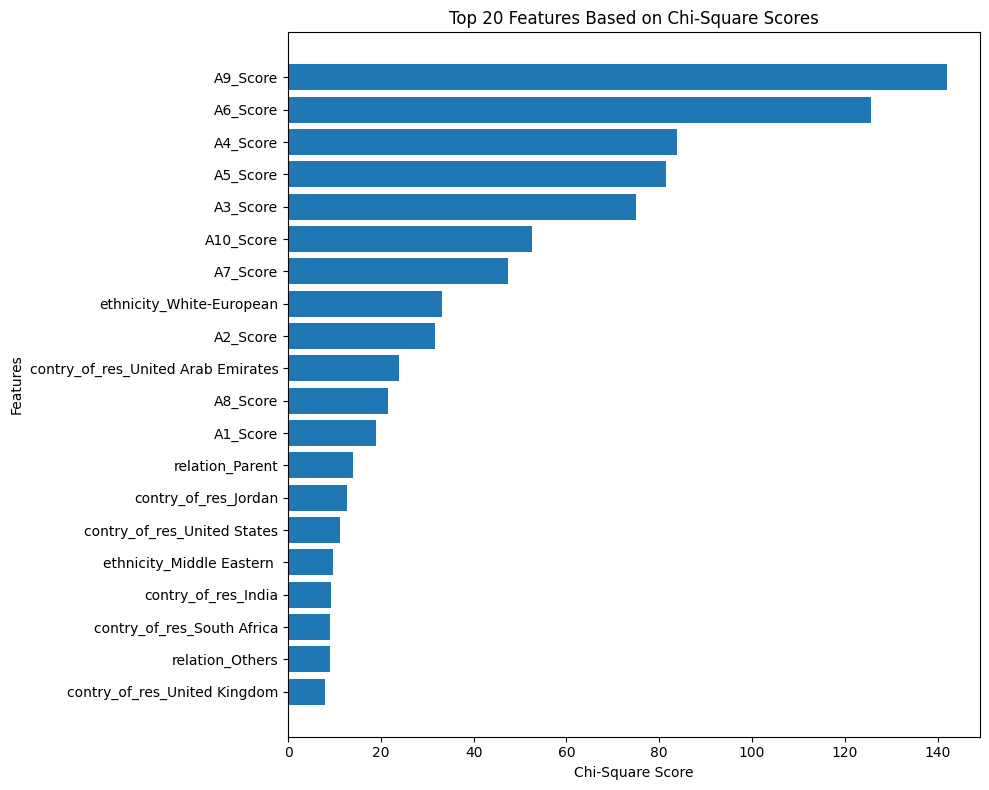

In [41]:
import matplotlib.pyplot as plt

# Select top 20 features
top20 = feature_scores.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top20["Feature"],
    top20["Chi2 Score"]
)

plt.xlabel("Chi-Square Score")
plt.ylabel("Features")
plt.title("Top 20 Features Based on Chi-Square Scores")

# Highest score at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

**Evaluate with Cross-Validation**

In [42]:
import time
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score
)

**Evaluation Function**

In [43]:
def evaluate_model(
    model,
    model_name,
    X_train,
    y_train,
    X_test,
    y_test,
    k=20
):

    numeric_features = ["age"]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", MinMaxScaler(), numeric_features)
        ],
        remainder="passthrough"
    )

    pipeline = Pipeline([
        ("scaler", preprocessor),
        ("selector", SelectKBest(chi2, k=k)),
        ("classifier", model)
    ])

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1"
    }

    # -------------------
    # Cross Validation
    # -------------------

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    # -------------------
    # Training
    # -------------------

    start_train = time.time()

    pipeline.fit(X_train, y_train)

    train_time = time.time() - start_train

    # -------------------
    # Prediction
    # -------------------

    start_pred = time.time()

    y_pred = pipeline.predict(X_test)

    prediction_time = time.time() - start_pred

    # -------------------
    # ROC-AUC
    # -------------------

    try:
        y_prob = pipeline.predict_proba(X_test)[:,1]
        roc_auc = roc_auc_score(y_test, y_prob)

    except:

        try:
            y_score = pipeline.decision_function(X_test)
            roc_auc = roc_auc_score(y_test, y_score)

        except:
            roc_auc = np.nan

    # -------------------
    # Save Results
    # -------------------

    results = {

        "Model": model_name,

        "CV Accuracy": cv_results["test_accuracy"].mean(),
        "CV Std": cv_results["test_accuracy"].std(),

        "Test Accuracy": accuracy_score(y_test, y_pred),

        "Precision": precision_score(y_test, y_pred),

        "Recall": recall_score(y_test, y_pred),

        "F1 Score": f1_score(y_test, y_pred),

        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),

        "MCC": matthews_corrcoef(y_test, y_pred),

        "Cohen Kappa": cohen_kappa_score(y_test, y_pred),

        "ROC AUC": roc_auc,

        "Train Time (s)": train_time,

        "Prediction Time (s)": prediction_time
    }

    return results, pipeline

**Models**

In [44]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import GaussianNB

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from xgboost import XGBClassifier

**Dictionary**

In [45]:
models = {

    "Naive Bayes":
        GaussianNB(),

    "KNN":
        KNeighborsClassifier(),

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
}

Evaluate Every Model

In [46]:
results = []

trained_models = {}

for name, model in models.items():

    print(f"Running {name}...")

    res, pipe = evaluate_model(
        model,
        name,
        X_train,
        y_train,
        X_test,
        y_test
    )

    results.append(res)

    trained_models[name] = pipe

Running Naive Bayes...
Running KNN...
Running Logistic Regression...
Running SVM...
Running Decision Tree...
Running Random Forest...
Running XGBoost...


In [47]:
results_df = pd.DataFrame(results)

results_df = results_df.round(4)

display(results_df)

,Model,CV Accuracy,CV Std,Test Accuracy,Precision,Recall,F1 Score,Balanced Accuracy,MCC,Cohen Kappa,ROC AUC,Train Time (s),Prediction Time (s)
0,Naive Bayes,0.8207,0.0993,0.8201,1.0000,0.4957,0.6629,0.7479,0.6224,0.5585,0.9875,0.0114,0.0049
1,KNN,0.9319,0.0121,0.9543,0.8923,0.9915,0.9393,0.9626,0.9060,0.9028,0.9893,0.0102,0.0129
2,Logistic Regression,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0153,0.0057
3,SVM,0.9803,0.0093,0.9787,0.9741,0.9658,0.9700,0.9758,0.9534,0.9534,0.9989,0.0478,0.0081
4,Decision Tree,0.8900,0.0177,0.8902,0.8293,0.8718,0.8500,0.8861,0.7641,0.7635,0.8861,0.0111,0.0042
5,Random Forest,0.9503,0.0196,0.9695,0.9496,0.9658,0.9576,0.9687,0.9339,0.9338,0.9958,0.1798,0.0134
6,XGBoost,0.9529,0.0096,0.9695,0.9350,0.9829,0.9583,0.9725,0.9350,0.9343,0.9981,0.0531,0.0073


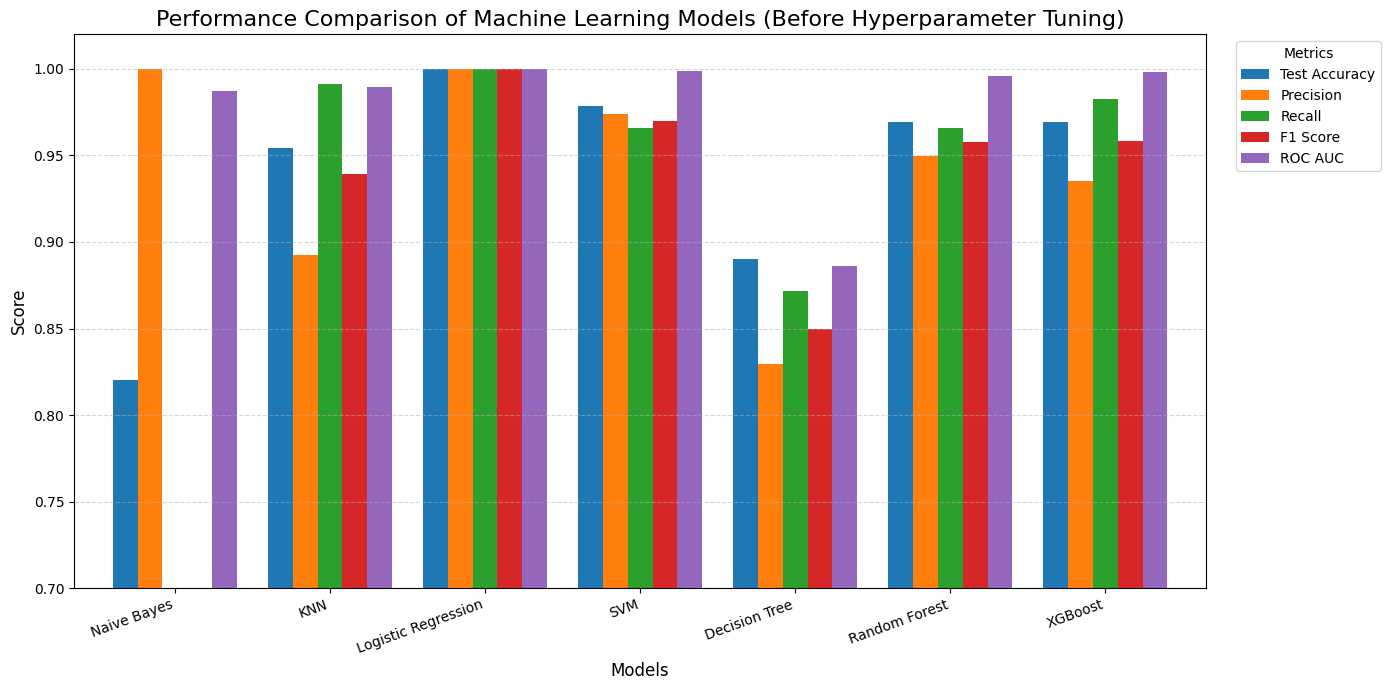

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics to plot
metrics = [
    "Test Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC"
]

plot_df = results_df.set_index("Model")[metrics]

# Plot
ax = plot_df.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.8
)

# Formatting
plt.title("Performance Comparison of Machine Learning Models (Before Hyperparameter Tuning)", fontsize=16)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0.7, 1.02)
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Show values on bars

plt.legend(title="Metrics", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.show()

Ranking:

In [49]:
results_df = pd.DataFrame(results)

# Rank models
ranking_df = results_df.sort_values(
    by=["CV Accuracy", "CV Std", "F1 Score", "ROC AUC"],
    ascending=[False, True, False, False]
).reset_index(drop=True)

ranking_df.round(4)

,Model,CV Accuracy,CV Std,Test Accuracy,Precision,Recall,F1 Score,Balanced Accuracy,MCC,Cohen Kappa,ROC AUC,Train Time (s),Prediction Time (s)
0,Logistic Regression,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0153,0.0057
1,SVM,0.9803,0.0093,0.9787,0.9741,0.9658,0.9700,0.9758,0.9534,0.9534,0.9989,0.0478,0.0081
2,XGBoost,0.9529,0.0096,0.9695,0.9350,0.9829,0.9583,0.9725,0.9350,0.9343,0.9981,0.0531,0.0073
3,Random Forest,0.9503,0.0196,0.9695,0.9496,0.9658,0.9576,0.9687,0.9339,0.9338,0.9958,0.1798,0.0134
4,KNN,0.9319,0.0121,0.9543,0.8923,0.9915,0.9393,0.9626,0.9060,0.9028,0.9893,0.0102,0.0129
5,Decision Tree,0.8900,0.0177,0.8902,0.8293,0.8718,0.8500,0.8861,0.7641,0.7635,0.8861,0.0111,0.0042
6,Naive Bayes,0.8207,0.0993,0.8201,1.0000,0.4957,0.6629,0.7479,0.6224,0.5585,0.9875,0.0114,0.0049


# Hyperparameter Tuning

**Generic Hyperparameter Tuning Function**

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score
)

def tune_model(
    model,
    param_grid,
    model_name,
    X_train,
    y_train,
    X_test,
    y_test,
    k=20,
    n_iter=20
):

    # Scale only numerical features
    numeric_features = ["age"]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", MinMaxScaler(), numeric_features)
        ],
        remainder="passthrough"
    )

    # Pipeline
    pipeline = Pipeline([
        ("scaler", preprocessor),
        ("selector", SelectKBest(score_func=chi2, k=k)),
        ("classifier", model)
    ])

    # 5-Fold CV
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # Random Search
    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring="accuracy",
        cv=cv,
        n_jobs=-1,
        random_state=42
    )

    # Train
    random_search.fit(X_train, y_train)

    # Best model
    best_model = random_search.best_estimator_

    # Prediction
    y_pred = best_model.predict(X_test)

    # ROC-AUC
    try:
        y_prob = best_model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)

    except:
        try:
            y_score = best_model.decision_function(X_test)
            roc_auc = roc_auc_score(y_test, y_score)
        except:
            roc_auc = np.nan

    # Save results
    results = {

        "Model": model_name,

        "Best CV Accuracy": random_search.best_score_,

        "Test Accuracy": accuracy_score(y_test, y_pred),

        "Precision": precision_score(y_test, y_pred),

        "Recall": recall_score(y_test, y_pred),

        "F1 Score": f1_score(y_test, y_pred),

        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),

        "MCC": matthews_corrcoef(y_test, y_pred),

        "Cohen Kappa": cohen_kappa_score(y_test, y_pred),

        "ROC AUC": roc_auc,

        "Best Parameters": random_search.best_params_
    }

    return results, best_model

In [51]:
# ============================
# Hyperparameter Search Space
# ============================

param_grids = {

    "Naive Bayes": {
        "classifier__var_smoothing": np.logspace(-9, -5, 20)
    },

    "KNN": {
        "classifier__n_neighbors": [3, 5, 7, 9, 11, 13],
        "classifier__weights": ["uniform", "distance"],
        "classifier__metric": ["euclidean", "manhattan"]
    },

    "Logistic Regression": {
        "classifier__C": np.logspace(-3, 3, 20),
        "classifier__solver": ["liblinear", "lbfgs"],
        "classifier__penalty": ["l2"]
    },

    "SVM": {
        "classifier__C": np.logspace(-2, 2, 20),
        "classifier__kernel": ["linear", "rbf"],
        "classifier__gamma": ["scale", "auto"]
    },

    "Decision Tree": {
        "classifier__criterion": ["gini", "entropy"],
        "classifier__max_depth": [None, 3, 5, 10, 15, 20],
        "classifier__min_samples_split": [2, 5, 10],
        "classifier__min_samples_leaf": [1, 2, 4]
    },

    "Random Forest": {
        "classifier__n_estimators": [100, 200, 300, 500],
        "classifier__max_depth": [None, 5, 10, 20],
        "classifier__min_samples_split": [2, 5, 10],
        "classifier__min_samples_leaf": [1, 2, 4],
        "classifier__bootstrap": [True, False]
    },

    "XGBoost": {
        "classifier__n_estimators": [100, 200, 300],
        "classifier__max_depth": [3, 5, 7, 10],
        "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "classifier__subsample": [0.8, 0.9, 1.0],
        "classifier__colsample_bytree": [0.8, 0.9, 1.0]
    }

}

In [52]:
# ====================================
# Tune All Models
# ====================================

tuned_results = []
tuned_models = {}

for model_name, model in models.items():

    print("=" * 60)
    print(f"Tuning {model_name}...")
    print("=" * 60)

    result2, best_model = tune_model(
        model=model,
        param_grid=param_grids[model_name],
        model_name=model_name,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        k=20,
        n_iter=20
    )

    tuned_results.append(result2)
    tuned_models[model_name] = best_model

    print("Best Parameters:")
    print(result2["Best Parameters"])

    print(f"Best CV Accuracy : {result2['Best CV Accuracy']:.4f}")
    print(f"Test Accuracy    : {result2['Test Accuracy']:.4f}")
    print()

# ====================================
# Convert Results to Table
# ====================================

tuned_results_df = pd.DataFrame(tuned_results)

# Display the table
# display(tuned_results_df)

# Or simply:
print(tuned_results_df)

Tuning Naive Bayes...
Best Parameters:
{'classifier__var_smoothing': np.float64(1e-05)}
Best CV Accuracy : 0.8705
Test Accuracy    : 0.9299

Tuning KNN...
Best Parameters:
{'classifier__weights': 'distance', 'classifier__n_neighbors': 11, 'classifier__metric': 'manhattan'}
Best CV Accuracy : 0.9437
Test Accuracy    : 0.9482

Tuning Logistic Regression...
Best Parameters:
{'classifier__solver': 'lbfgs', 'classifier__penalty': 'l2', 'classifier__C': np.float64(0.6951927961775606)}
Best CV Accuracy : 1.0000
Test Accuracy    : 1.0000

Tuning SVM...
Best Parameters:
{'classifier__kernel': 'linear', 'classifier__gamma': 'auto', 'classifier__C': np.float64(0.29763514416313175)}
Best CV Accuracy : 1.0000
Test Accuracy    : 1.0000

Tuning Decision Tree...
Best Parameters:
{'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': 10, 'classifier__criterion': 'gini'}
Best CV Accuracy : 0.9058
Test Accuracy    : 0.9085

Tuning Random Forest...
Best Parameters

In [53]:
tuned_results_df = tuned_results_df.round({
    "Best CV Accuracy": 4,
    "Test Accuracy": 4,
    "Precision": 4,
    "Recall": 4,
    "F1 Score": 4,
    "Balanced Accuracy": 4,
    "MCC": 4,
    "Cohen Kappa": 4,
    "ROC AUC": 4,
    "Train Time (s)": 4,
    "Prediction Time (s)": 4
})

display(tuned_results_df)

,Model,Best CV Accuracy,Test Accuracy,Precision,Recall,F1 Score,Balanced Accuracy,MCC,Cohen Kappa,ROC AUC,Best Parameters
0,Naive Bayes,0.8705,0.9299,0.9700,0.8291,0.8940,0.9074,0.8479,0.8421,0.9875,{'classifier__var_smoothing': 1e-05}
1,KNN,0.9437,0.9482,0.8846,0.9829,0.9312,0.9559,0.8930,0.8898,0.9950,"{'classifier__weights': 'distance', 'classifie..."
2,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,"{'classifier__solver': 'lbfgs', 'classifier__p..."
3,SVM,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,"{'classifier__kernel': 'linear', 'classifier__..."
4,Decision Tree,0.9058,0.9085,0.8718,0.8718,0.8718,0.9004,0.8007,0.8007,0.9239,"{'classifier__min_samples_split': 2, 'classifi..."
5,Random Forest,0.9608,0.9695,0.9652,0.9487,0.9569,0.9649,0.9334,0.9333,0.9957,"{'classifier__n_estimators': 200, 'classifier_..."
6,XGBoost,0.9778,0.9939,0.9832,1.0000,0.9915,0.9953,0.9869,0.9868,0.9997,"{'classifier__subsample': 0.8, 'classifier__n_..."


ROC


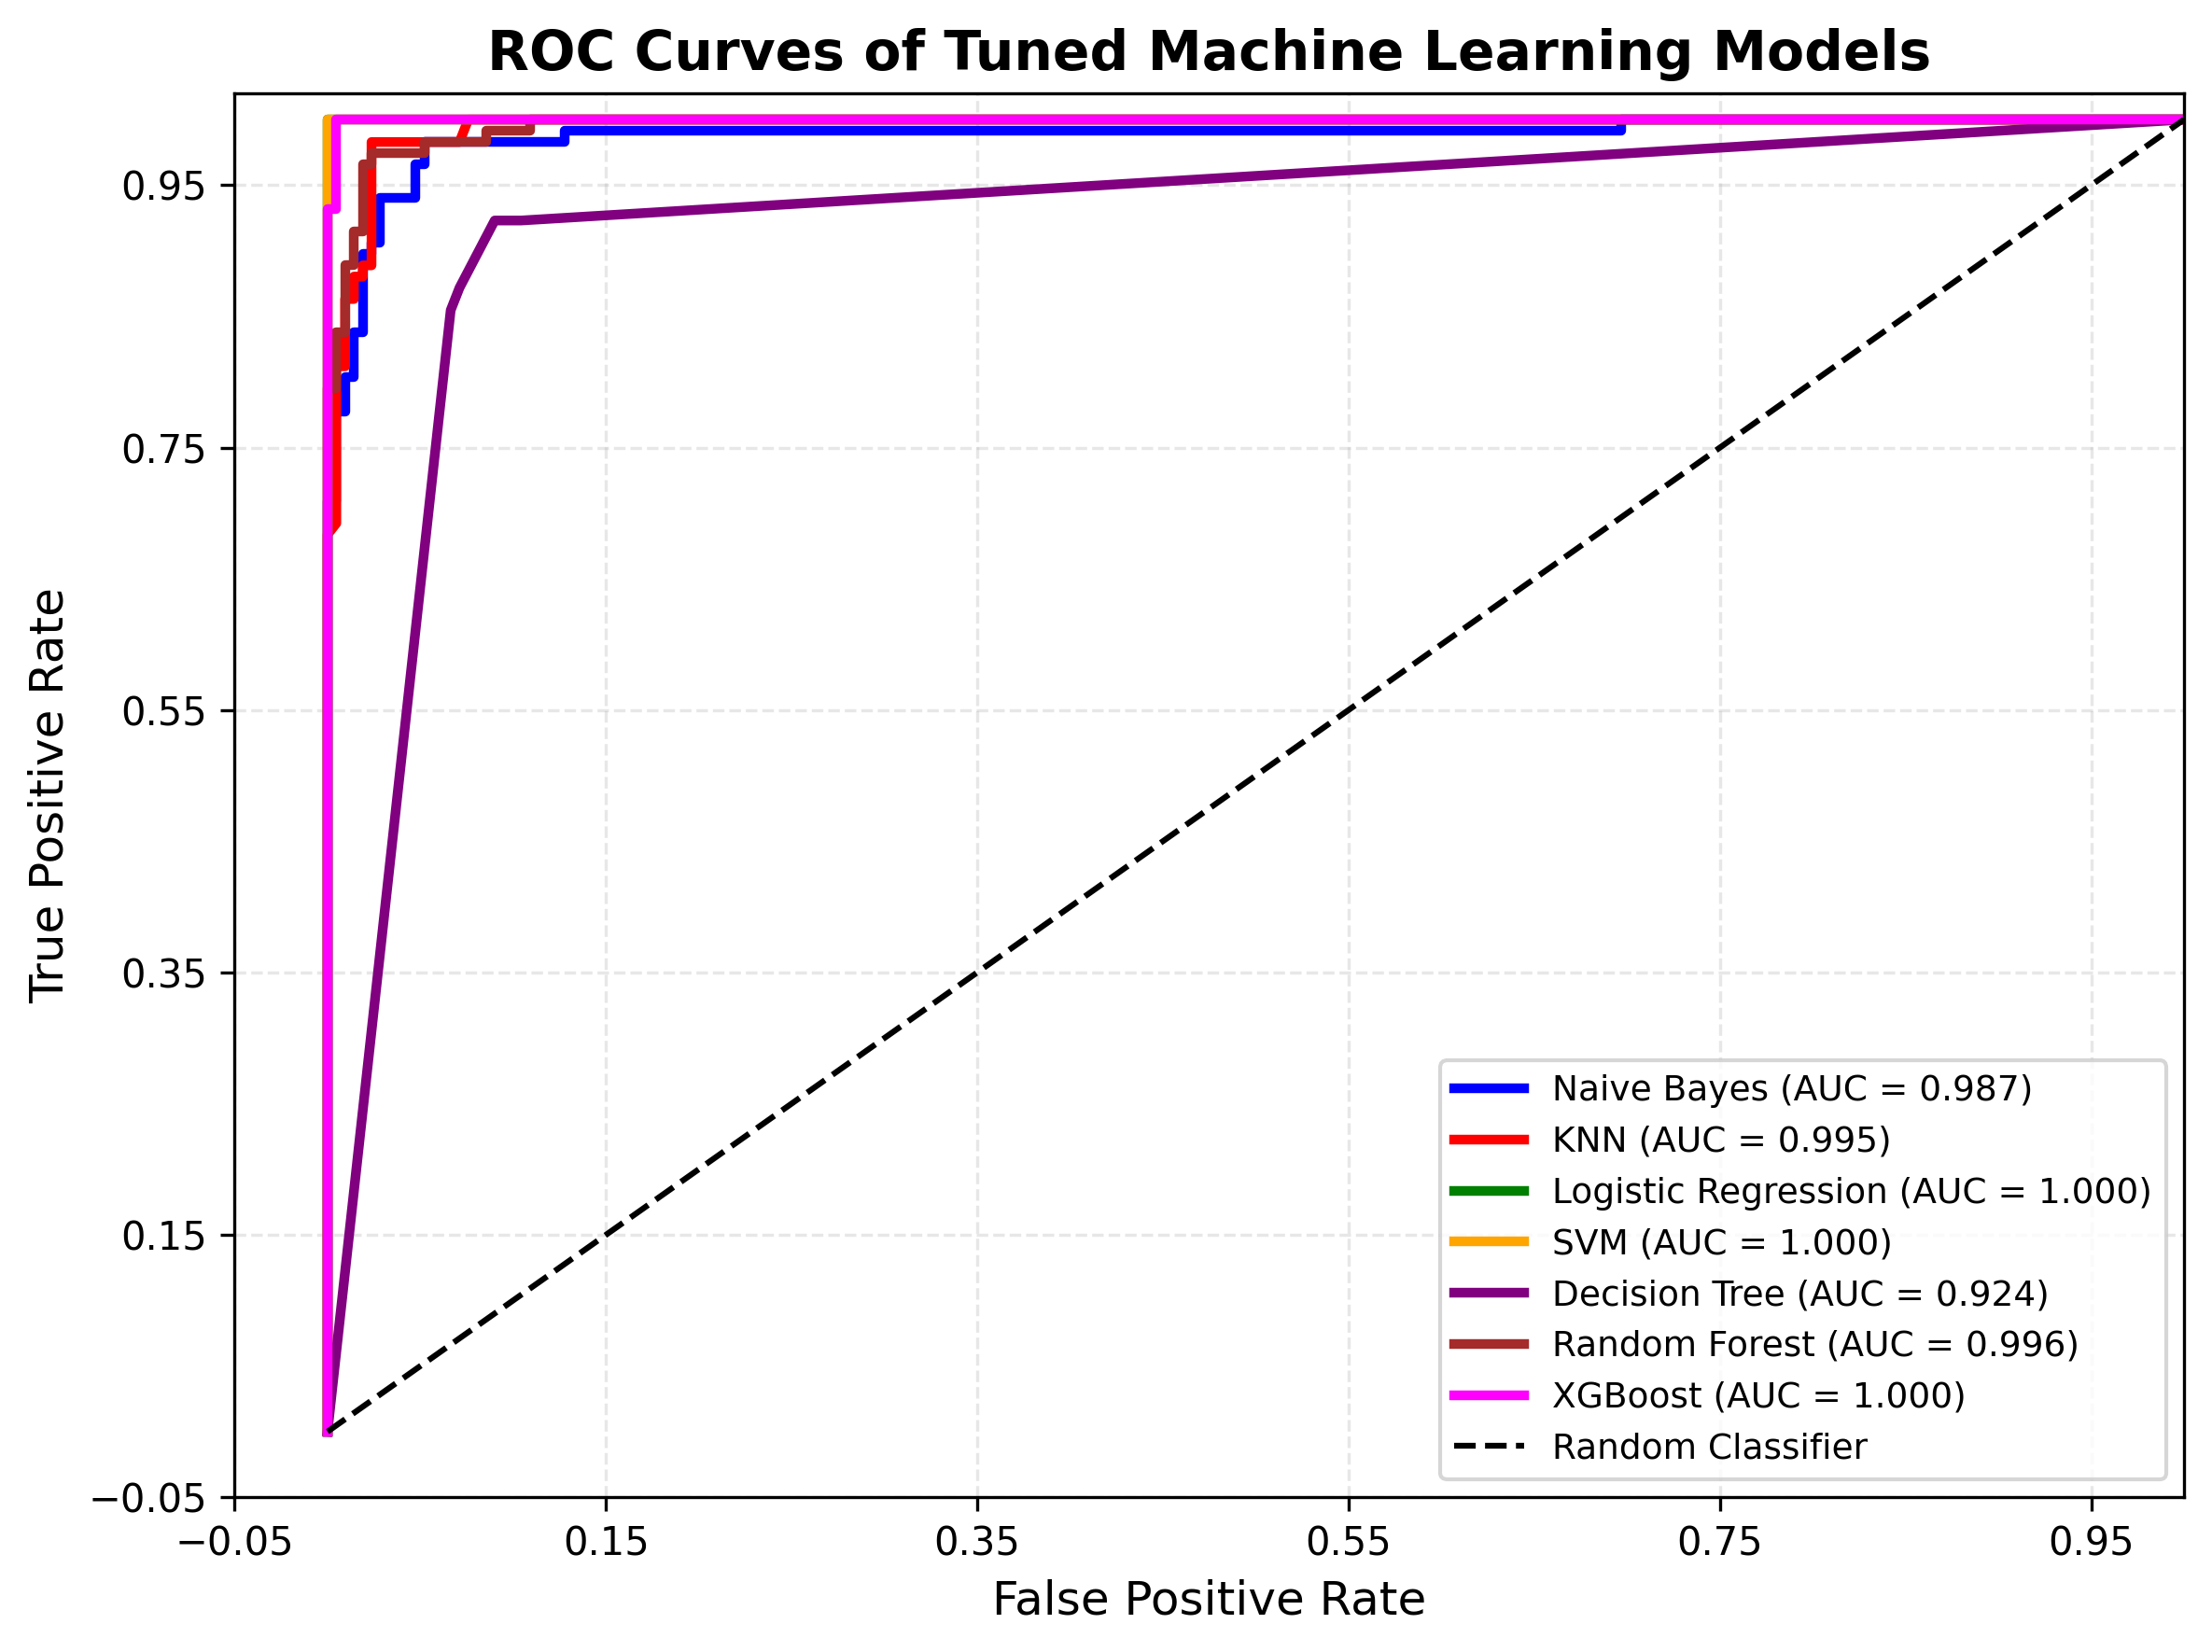

In [54]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# ====================================
# ROC Curve for Tuned Models
# ====================================

plt.figure(figsize=(8, 6), dpi=300)

colors = [
    "blue",
    "red",
    "green",
    "orange",
    "purple",
    "brown",
    "magenta"
]

for color, (model_name, model) in zip(colors, tuned_models.items()):

    # Get prediction scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    # Compute ROC
    fpr, tpr, _ = roc_curve(y_test, y_score)

    auc_score = roc_auc_score(y_test, y_score)

    # Plot
    plt.plot(
        fpr,
        tpr,
        linewidth=2.5,
        color=color,
        label=f"{model_name} (AUC = {auc_score:.3f})"
    )

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Random Classifier"
)

# Figure formatting
plt.xlim([0, 1])
plt.ylim([0, 1.02])

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.title(
    "ROC Curves of Tuned Machine Learning Models",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(np.arange(-.05, 1.01, 0.2))
plt.yticks(np.arange(-.05, 1.01, 0.2))

plt.grid(True, linestyle="--", alpha=0.3)

plt.legend(loc="lower right", fontsize=9)

plt.tight_layout()

plt.savefig(
    "ROC_Curve_Tuned_Models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

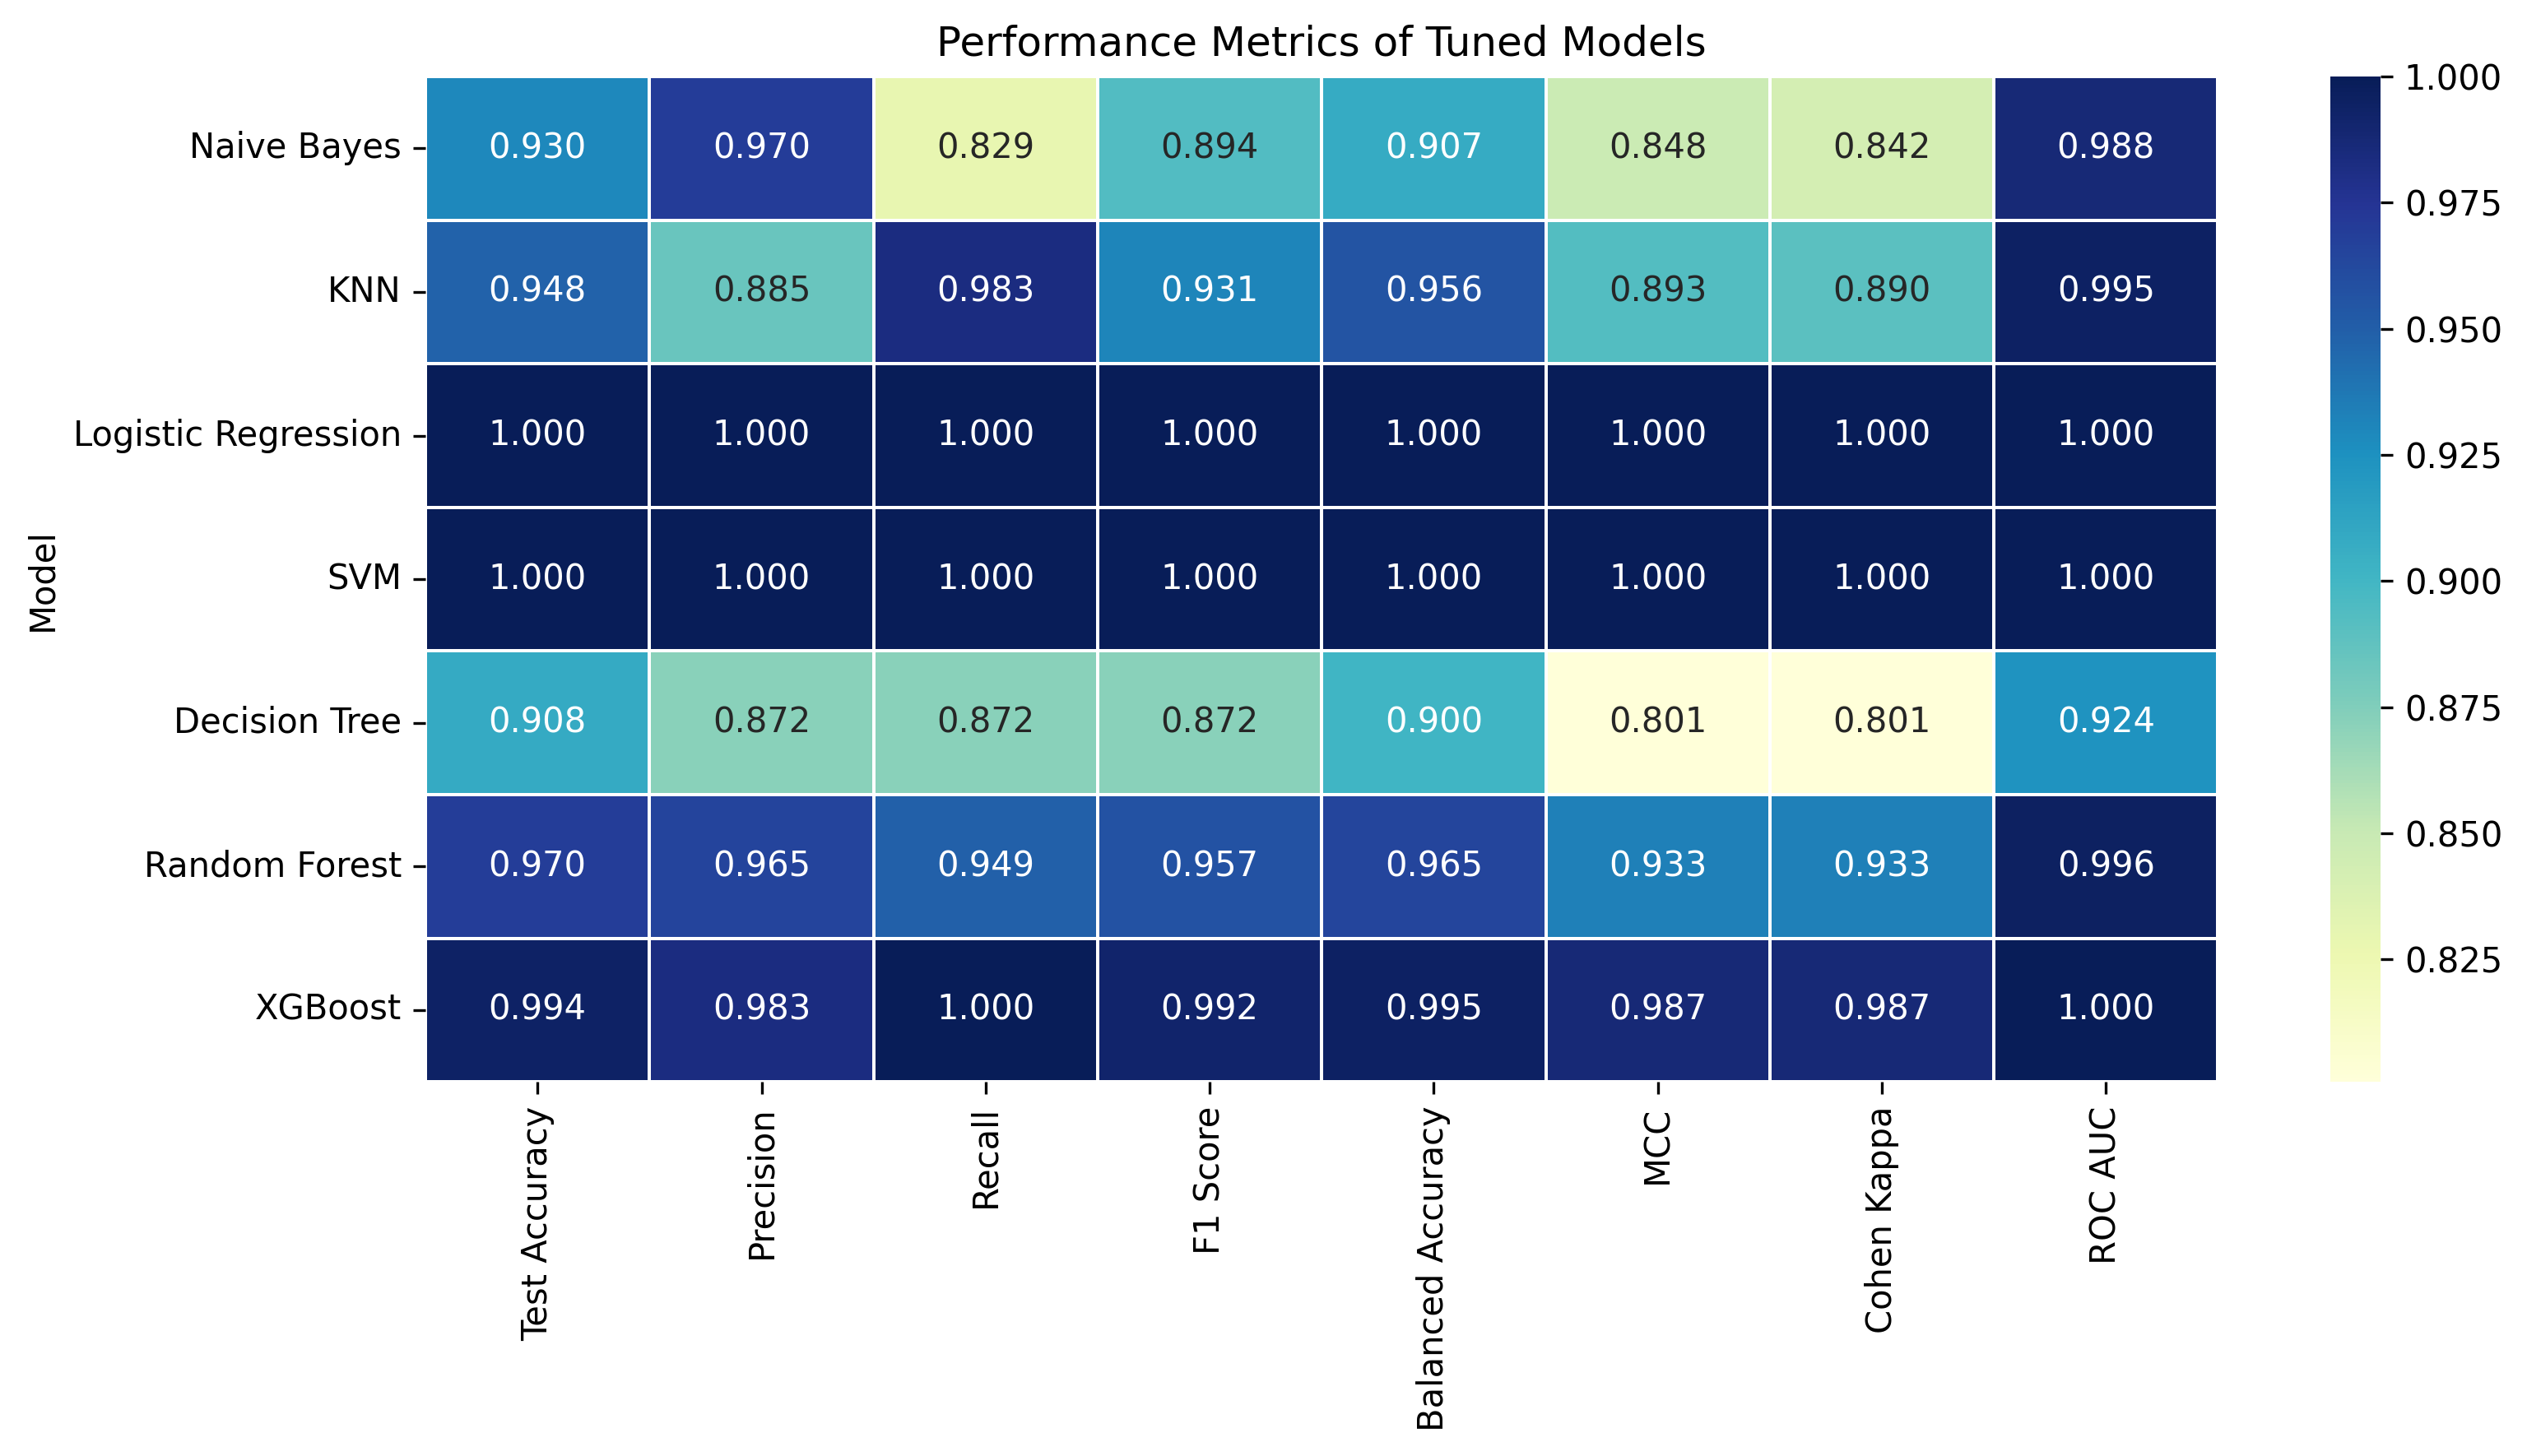

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

metrics = [
    "Test Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "Balanced Accuracy",
    "MCC",
    "Cohen Kappa",
    "ROC AUC"
]

heatmap_data = tuned_results_df.set_index("Model")[metrics]

plt.figure(figsize=(11,6), dpi=300)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Performance Metrics of Tuned Models")

plt.tight_layout()
plt.show()

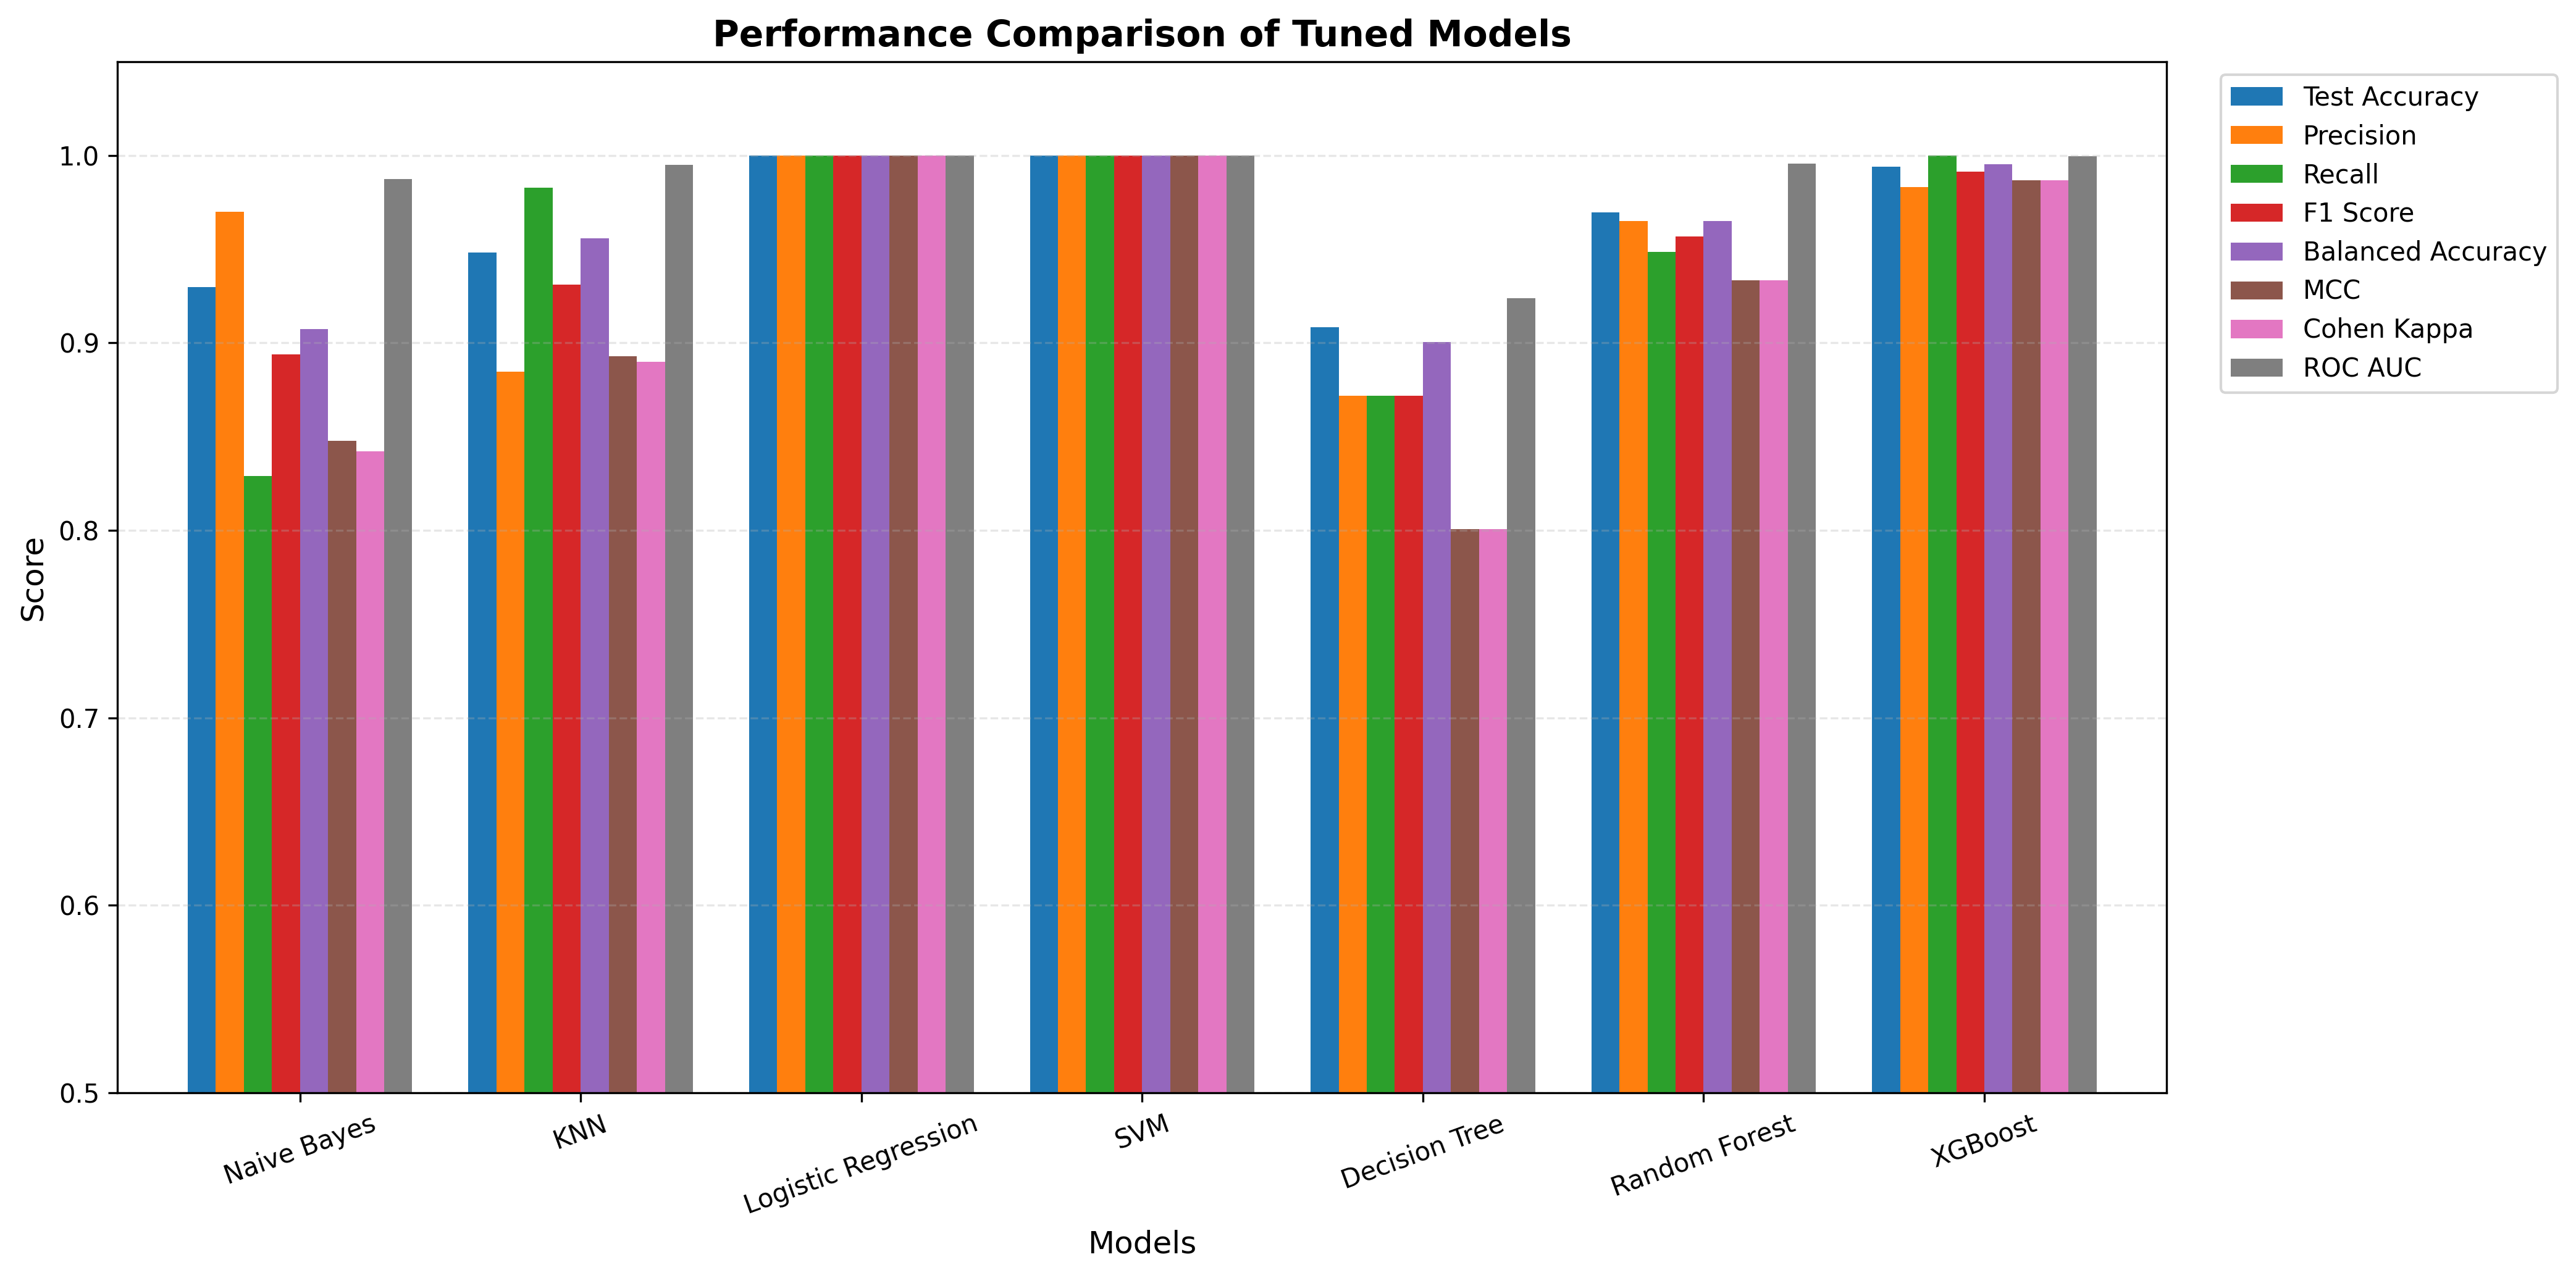

In [56]:
import matplotlib.pyplot as plt
import numpy as np

metrics = [
    "Test Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "Balanced Accuracy",
    "MCC",
    "Cohen Kappa",
    "ROC AUC"
]

plot_df = tuned_results_df.set_index("Model")[metrics]

fig, ax = plt.subplots(figsize=(14, 7), dpi=300)

plot_df.plot(kind="bar", ax=ax, width=0.8)

ax.set_ylim(0.5, 1.05)
ax.set_xlabel("Models", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Performance Comparison of Tuned Models", fontsize=14, fontweight="bold")

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig("Performance_Barplot.png", dpi=300, bbox_inches="tight")
plt.show()

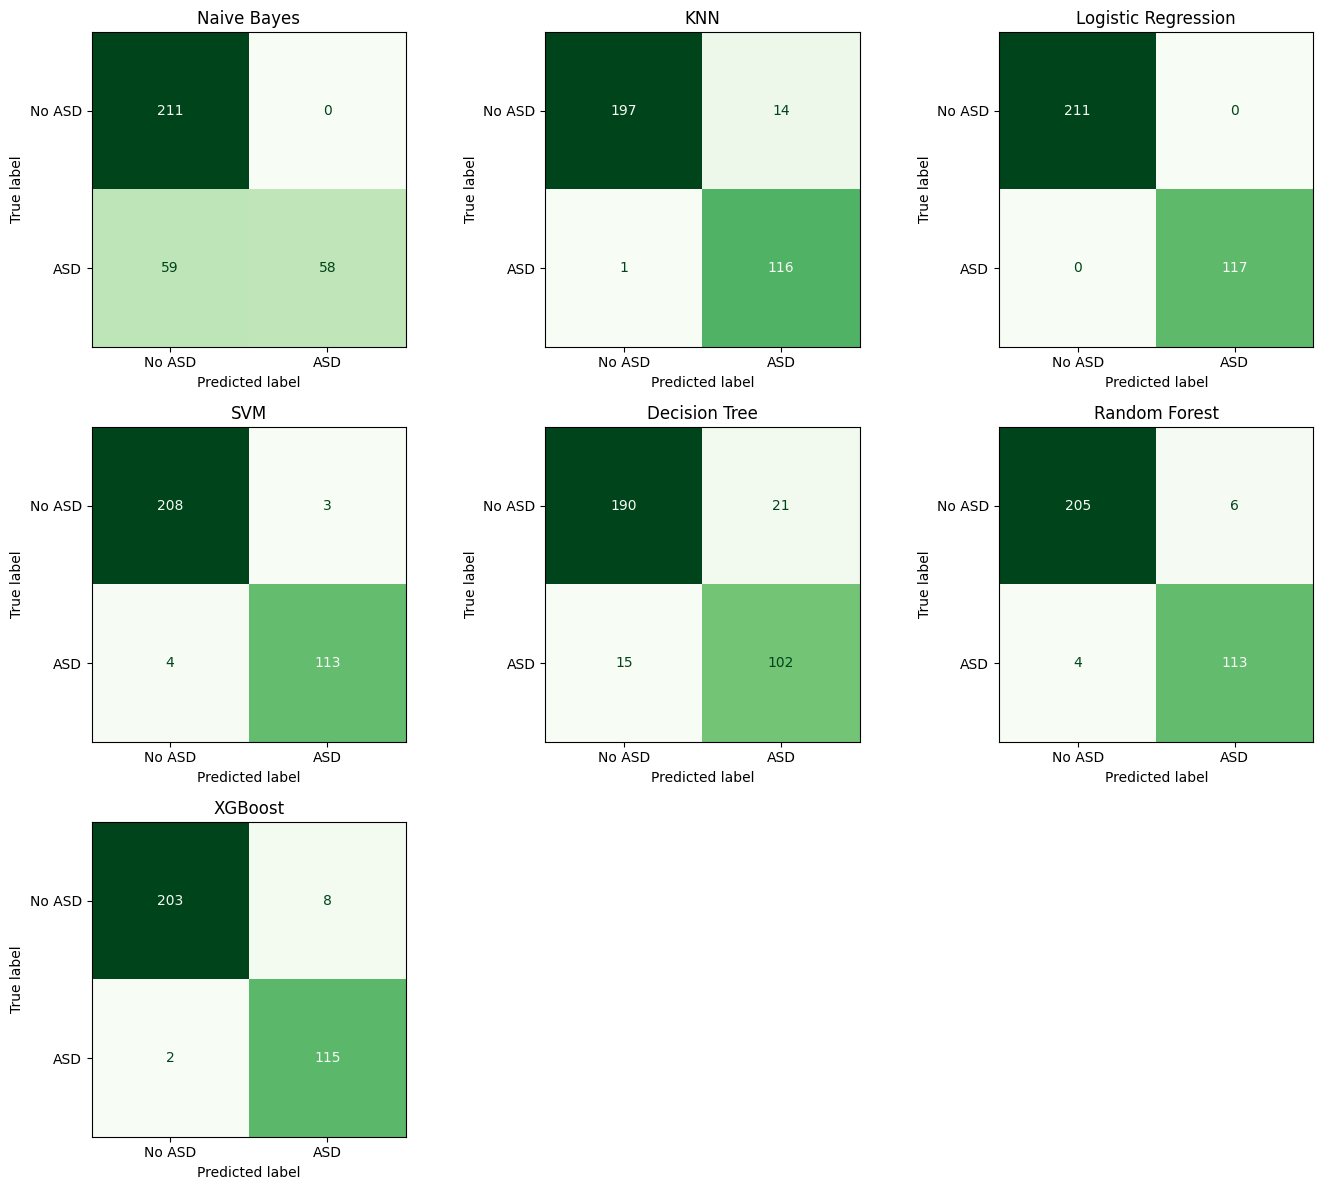

In [57]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.ravel()

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        ax=ax,
        cmap="Greens",
        colorbar=False,
        values_format="d",
        display_labels=["No ASD", "ASD"]
    )

    ax.set_title(name)

# Hide the unused axes
for ax in axes[len(trained_models):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

**ROC**

In [58]:
# Install SHAP
!pip install shap

# Import libraries
import shap
import numpy as np
import matplotlib.pyplot as plt

In [59]:
xgb_pipeline = tuned_models["XGBoost"]

Extract the preprocessing, selector, and classifier

In [60]:
# Transform training and test data
X_train_transformed = xgb_pipeline[:-1].transform(X_train)
X_test_transformed = xgb_pipeline[:-1].transform(X_test)

# Get trained classifier
xgb_model = xgb_pipeline.named_steps["classifier"]

# Get selected feature names
selector = xgb_pipeline.named_steps["selector"]
feature_names = X_train.columns[selector.get_support()].tolist()

print("Selected Features:")
print(feature_names)
print("Number of selected features:", len(feature_names))

Selected Features:
['A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'ethnicity_Middle Eastern ', 'ethnicity_White-European', 'contry_of_res_India', 'contry_of_res_Jordan', 'contry_of_res_South Africa', 'contry_of_res_United Arab Emirates', 'contry_of_res_United Kingdom', 'contry_of_res_United States', 'relation_Others', 'relation_Parent']
Number of selected features: 20


In [61]:
# Create the TreeExplainer
import shap

explainer = shap.TreeExplainer(xgb_model)

In [62]:
shap_values = explainer(X_test_transformed)

print(type(shap_values))
print(shap_values.values.shape)

<class 'shap._explanation.Explanation'>
(328, 20)


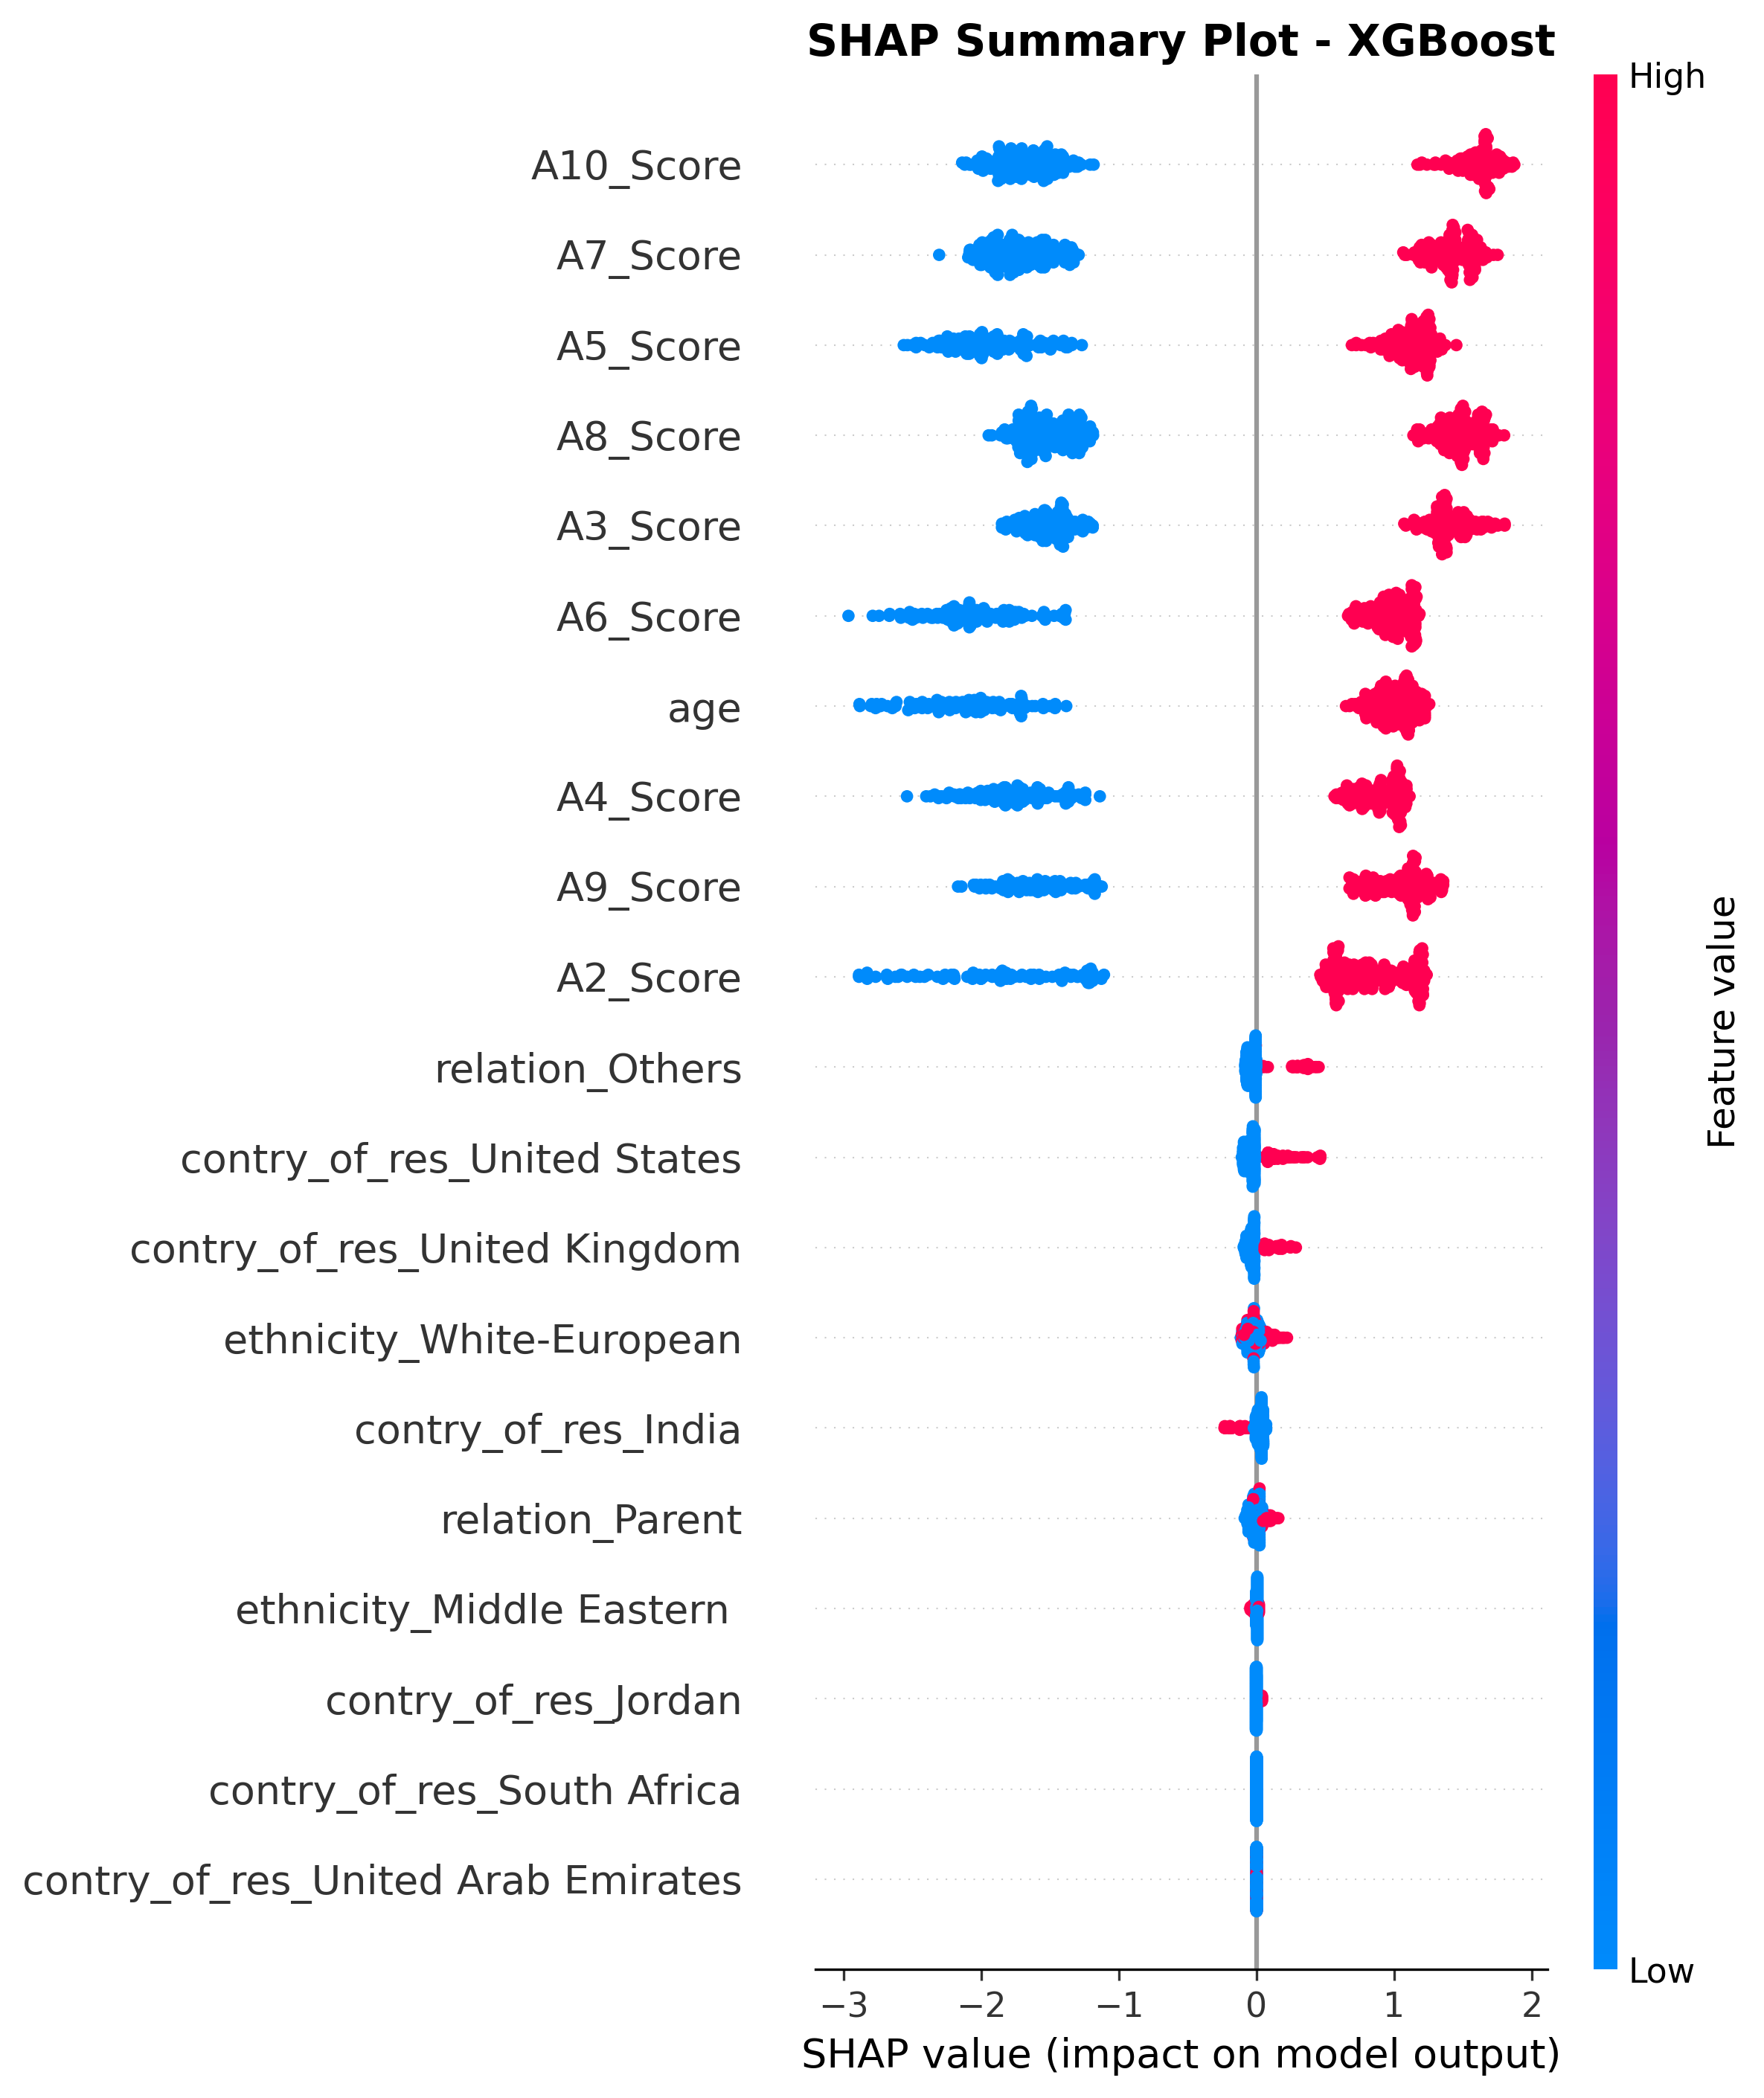

In [63]:
# SHAP Summary Plot
import matplotlib.pyplot as plt
import shap

plt.figure(figsize=(10, 6), dpi=300)

shap.summary_plot(
    shap_values,
    feature_names=feature_names,
    max_display=20,
    show=False
)

plt.title(
    "SHAP Summary Plot - XGBoost",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("XGBoost_SHAP_Summary.png", dpi=300)
plt.show()

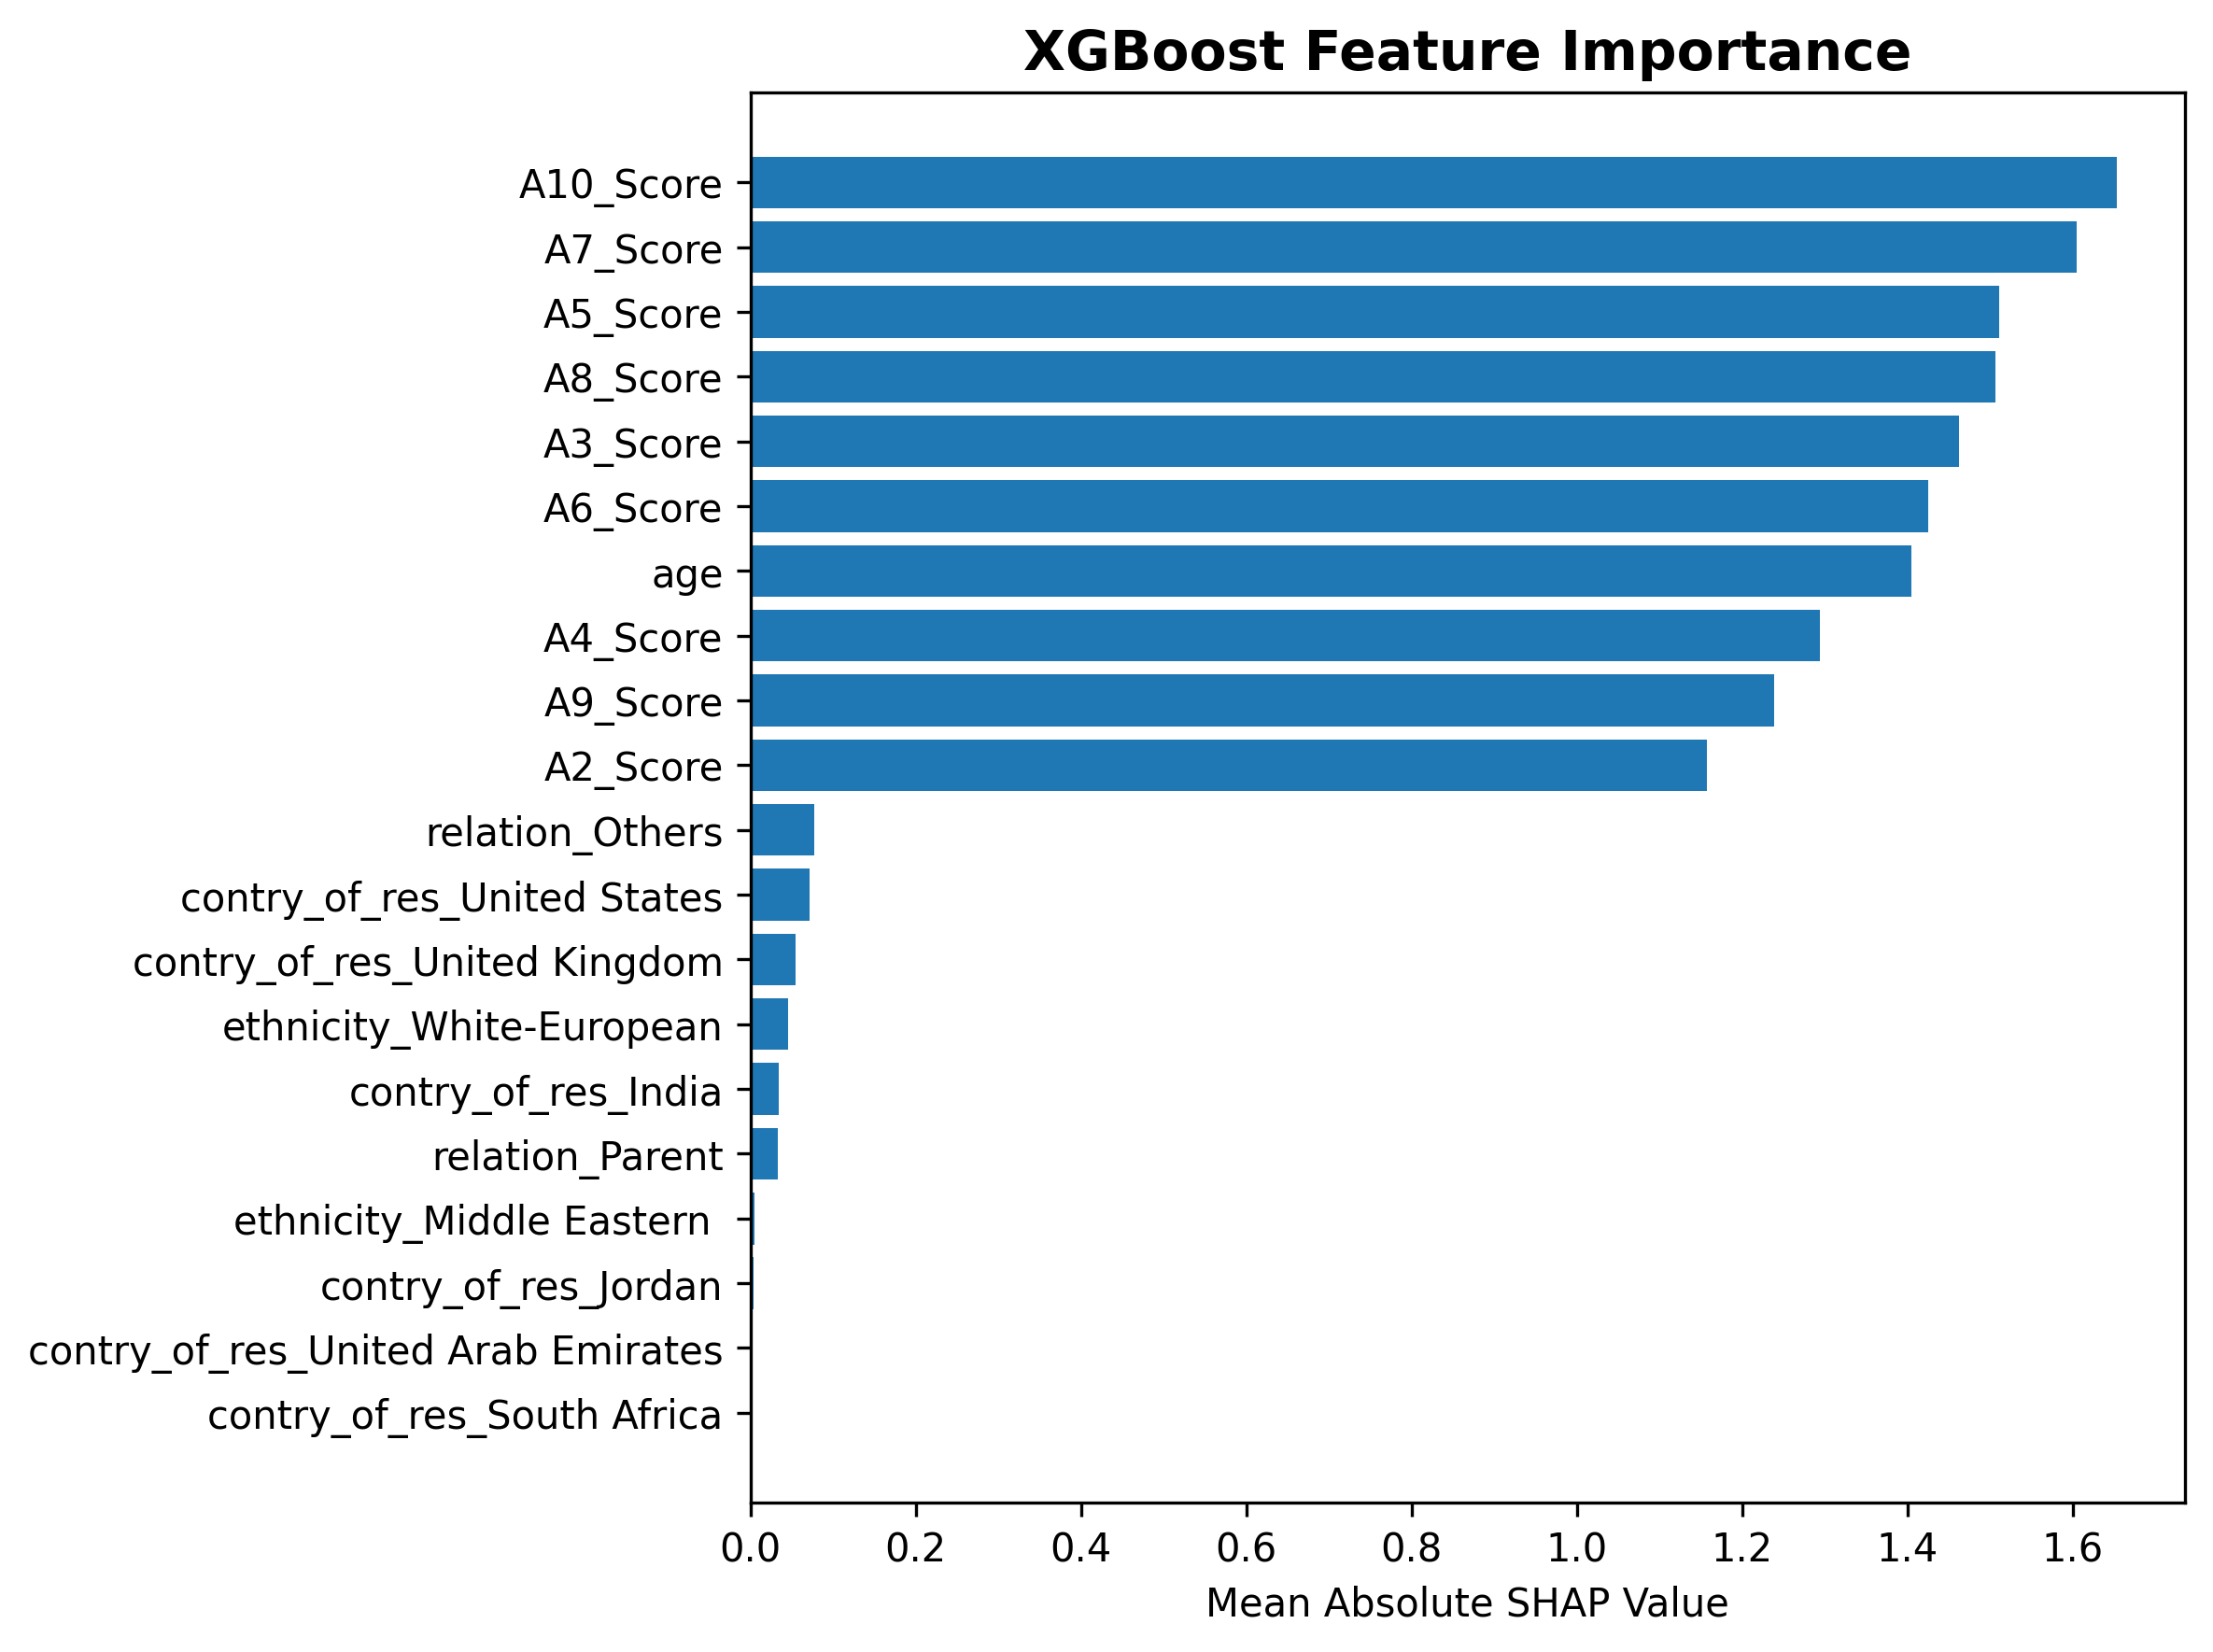

,Feature,Mean |SHAP|
8,A10_Score,1.653471
5,A7_Score,1.604667
3,A5_Score,1.511063
6,A8_Score,1.506513
1,A3_Score,1.462648
4,A6_Score,1.425840
9,age,1.405482
2,A4_Score,1.294130
7,A9_Score,1.238632
0,A2_Score,1.157135


In [64]:
# SHAP Feature Importance (Bar Plot)
import numpy as np
import pandas as pd

importance = np.abs(shap_values.values).mean(axis=0)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP|": importance
})

importance_df = importance_df.sort_values(
    by="Mean |SHAP|",
    ascending=False
)

plt.figure(figsize=(8, 6), dpi=300)

plt.barh(
    importance_df["Feature"][::-1],
    importance_df["Mean |SHAP|"][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.title(
    "XGBoost Feature Importance",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("XGBoost_SHAP_Bar.png", dpi=300)
plt.show()

importance_df

Most Important Feature: A10_Score


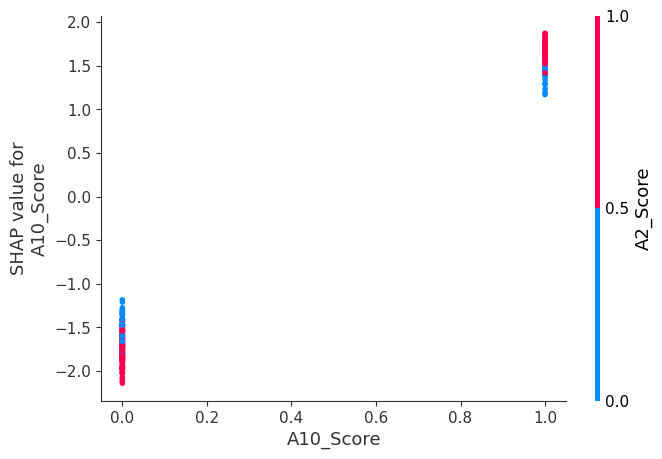

In [65]:
# Dependence Plot
best_feature = importance_df.iloc[0]["Feature"]

print("Most Important Feature:", best_feature)

shap.dependence_plot(
    best_feature,
    shap_values.values,
    X_test_transformed,
    feature_names=feature_names,
    interaction_index="auto"
)

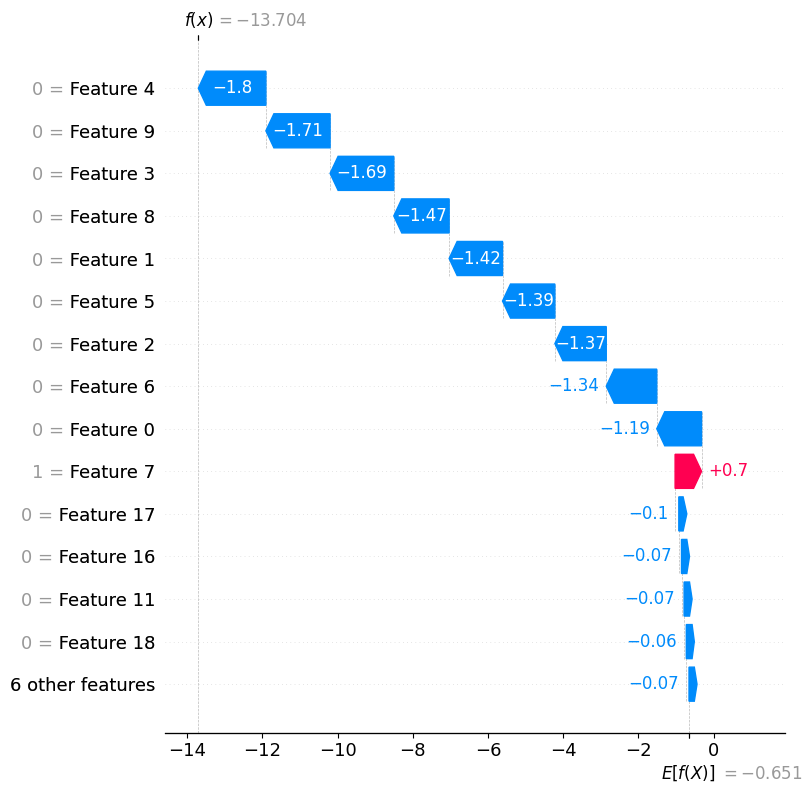

In [66]:
sample_index = 0

shap.plots.waterfall(
    shap_values[sample_index],
    max_display=15
)

In [67]:
# Save SHAP Feature Importance Table
importance_df.to_csv(
    "XGBoost_SHAP_Feature_Importance.csv",
    index=False
)

importance_df.head(20)
xgb_importance_df = importance_df.copy()

**Random Forest SHAP Explainability**

Selected Features:
['A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'ethnicity_Middle Eastern ', 'ethnicity_White-European', 'contry_of_res_India', 'contry_of_res_Jordan', 'contry_of_res_South Africa', 'contry_of_res_United Arab Emirates', 'contry_of_res_United Kingdom', 'contry_of_res_United States', 'relation_Others', 'relation_Parent']
<class 'shap._explanation.Explanation'>
(328, 20, 2)


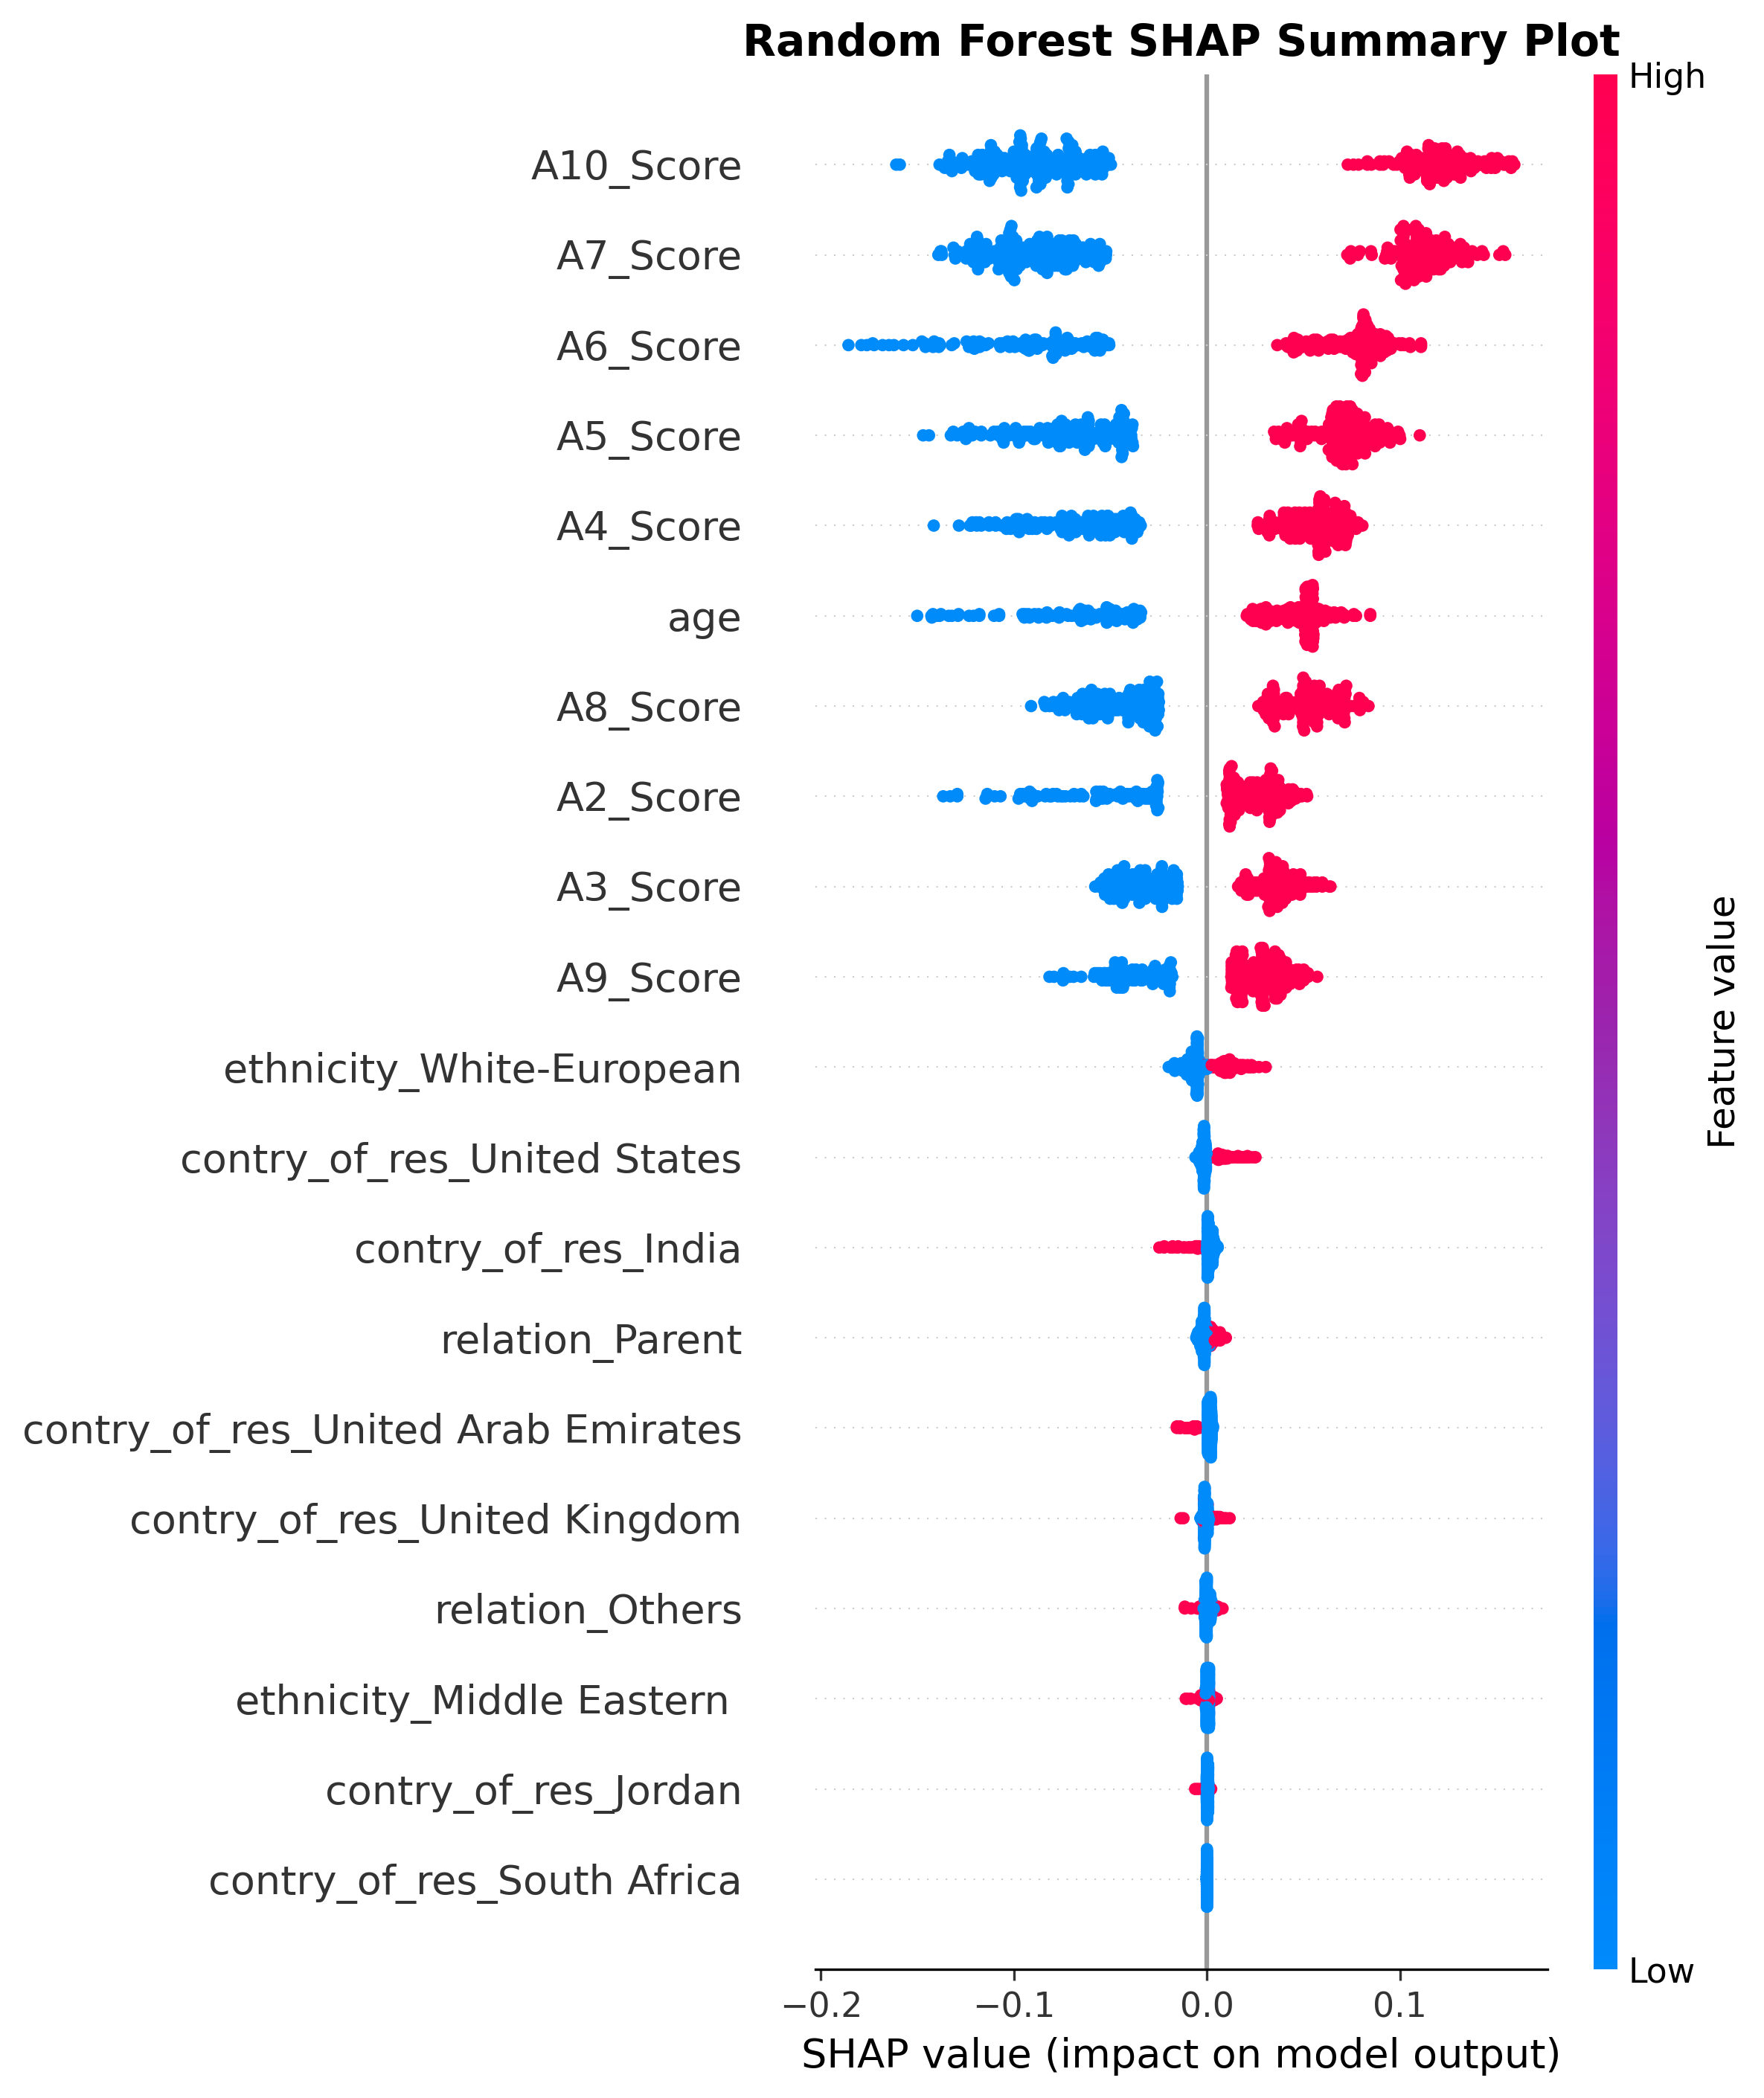

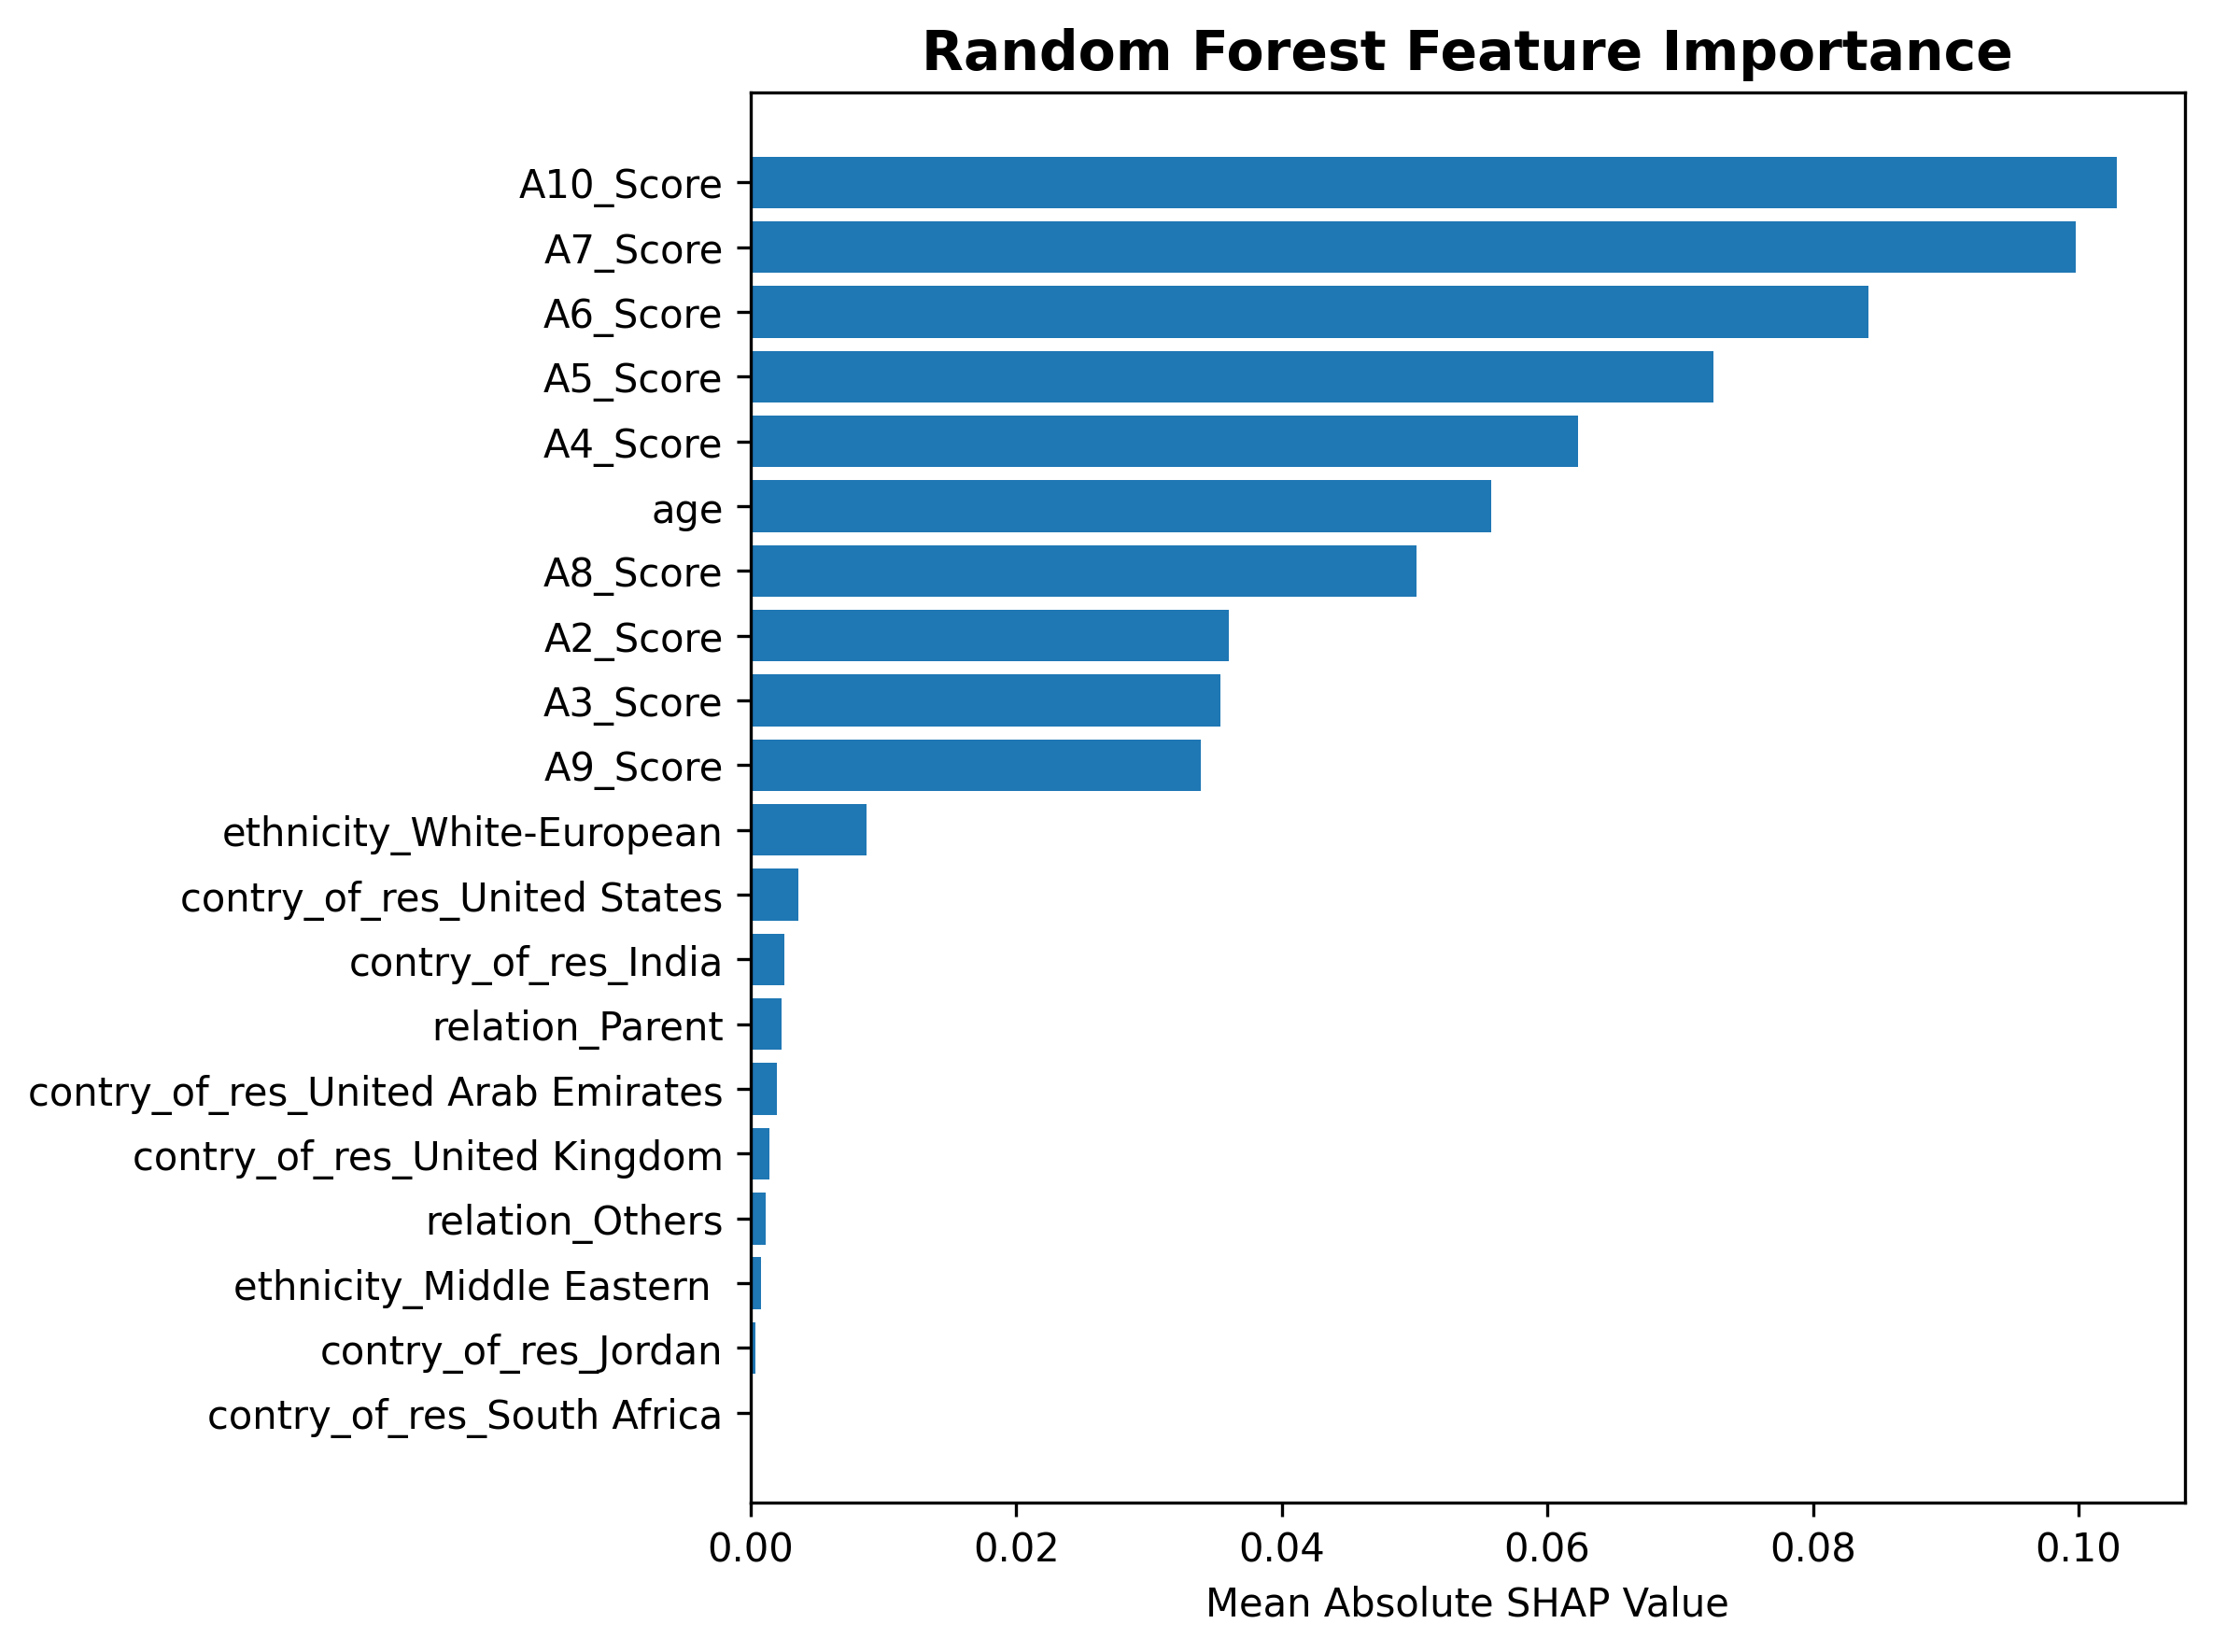

,Feature,Mean |SHAP|
8,A10_Score,0.102874
5,A7_Score,0.099820
4,A6_Score,0.084161
3,A5_Score,0.072510
2,A4_Score,0.062329
9,age,0.055752
6,A8_Score,0.050178
0,A2_Score,0.036049
1,A3_Score,0.035355
7,A9_Score,0.033916


Most Important Feature: A10_Score


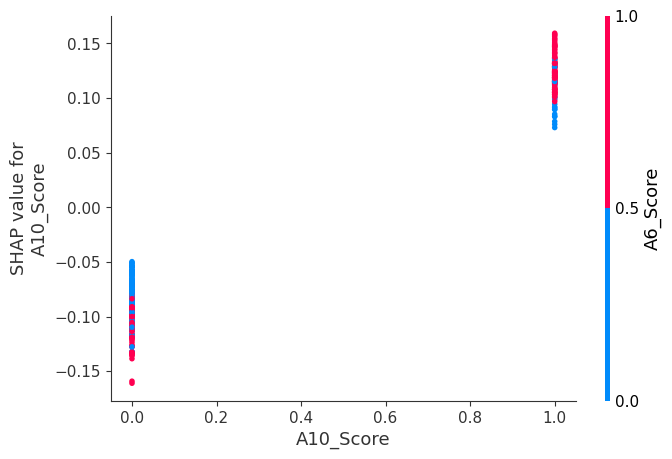

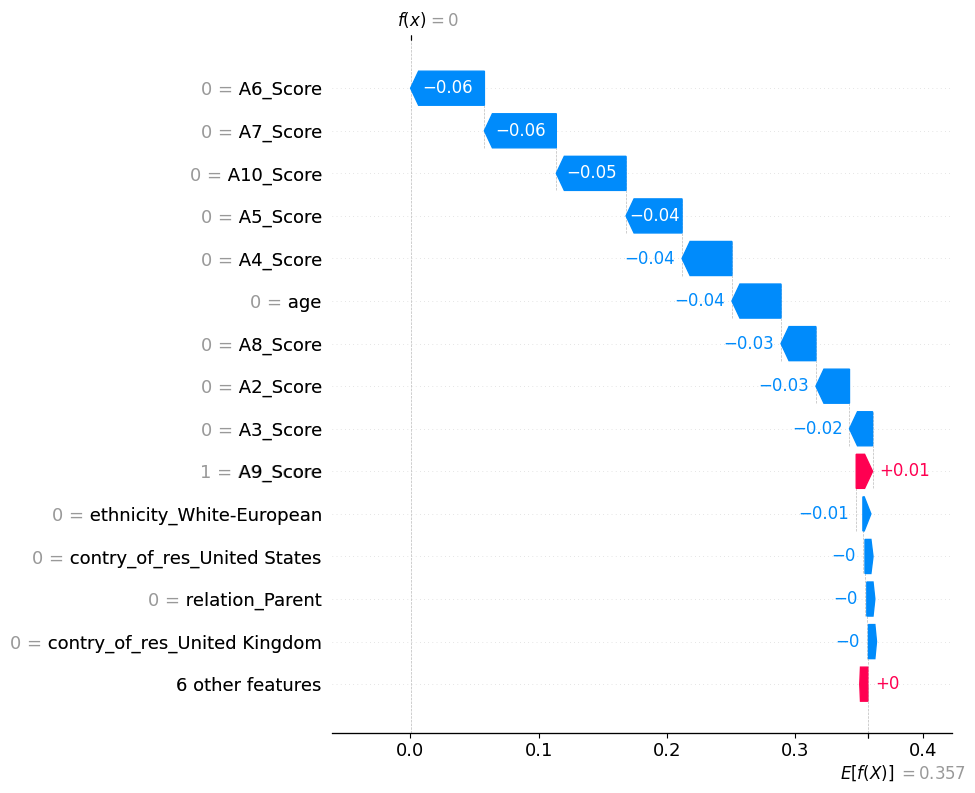

In [68]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# Random Forest SHAP Explainability
# =====================================================

# Load tuned Random Forest pipeline
rf_pipeline = tuned_models["Random Forest"]

# =====================================================
# Transform Data
# =====================================================

X_train_transformed = rf_pipeline[:-1].transform(X_train)
X_test_transformed = rf_pipeline[:-1].transform(X_test)

# =====================================================
# Get trained Random Forest model
# =====================================================

rf_model = rf_pipeline.named_steps["classifier"]

# =====================================================
# Selected Features
# =====================================================

selector = rf_pipeline.named_steps["selector"]

feature_names = X_train.columns[
    selector.get_support()
].tolist()

print("Selected Features:")
print(feature_names)

# =====================================================
# SHAP Explainer
# =====================================================

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer(X_test_transformed)

print(type(shap_values))
print(shap_values.values.shape)

# =====================================================
# Handle Binary Classification
# =====================================================

if len(shap_values.values.shape) == 3:

    shap_values = shap.Explanation(

        values=shap_values.values[:, :, 1],

        base_values=shap_values.base_values[:, 1],

        data=shap_values.data,

        feature_names=feature_names

    )

else:

    shap_values = shap.Explanation(

        values=shap_values.values,

        base_values=shap_values.base_values,

        data=shap_values.data,

        feature_names=feature_names

    )

# =====================================================
# SHAP Summary Plot
# =====================================================

plt.figure(figsize=(10,6), dpi=300)

shap.summary_plot(
    shap_values,
    feature_names=feature_names,
    max_display=20,
    show=False
)

plt.title(
    "Random Forest SHAP Summary Plot",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "RF_SHAP_Summary.png",
    dpi=300
)

plt.show()

# =====================================================
# SHAP Feature Importance
# =====================================================

importance = np.abs(
    shap_values.values
).mean(axis=0)

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Mean |SHAP|": importance

})

importance_df = importance_df.sort_values(

    by="Mean |SHAP|",

    ascending=False

)

plt.figure(figsize=(8,6), dpi=300)

plt.barh(

    importance_df["Feature"][::-1],

    importance_df["Mean |SHAP|"][::-1]

)

plt.xlabel("Mean Absolute SHAP Value")

plt.title(
    "Random Forest Feature Importance",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "RF_SHAP_Bar.png",
    dpi=300
)

plt.show()

# =====================================================
# Save Importance Table
# =====================================================

importance_df.to_csv(
    "RF_SHAP_Feature_Importance.csv",
    index=False
)
rf_importance_df = importance_df.copy()

display(importance_df.head(20))

# =====================================================
# SHAP Dependence Plot
# =====================================================

best_feature = importance_df.iloc[0]["Feature"]

print("Most Important Feature:", best_feature)

shap.dependence_plot(

    best_feature,

    shap_values.values,

    X_test_transformed,

    feature_names=feature_names,

    interaction_index="auto"

)

# =====================================================
# SHAP Waterfall Plot
# =====================================================

sample_index = 0

shap.plots.waterfall(

    shap_values[sample_index],

    max_display=15

)

# **Logistic Regression SHAP Explainability**#

Selected Features:
['A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'ethnicity_Middle Eastern ', 'ethnicity_White-European', 'contry_of_res_India', 'contry_of_res_Jordan', 'contry_of_res_South Africa', 'contry_of_res_United Arab Emirates', 'contry_of_res_United Kingdom', 'contry_of_res_United States', 'relation_Others', 'relation_Parent']
<class 'shap._explanation.Explanation'>
(328, 20)


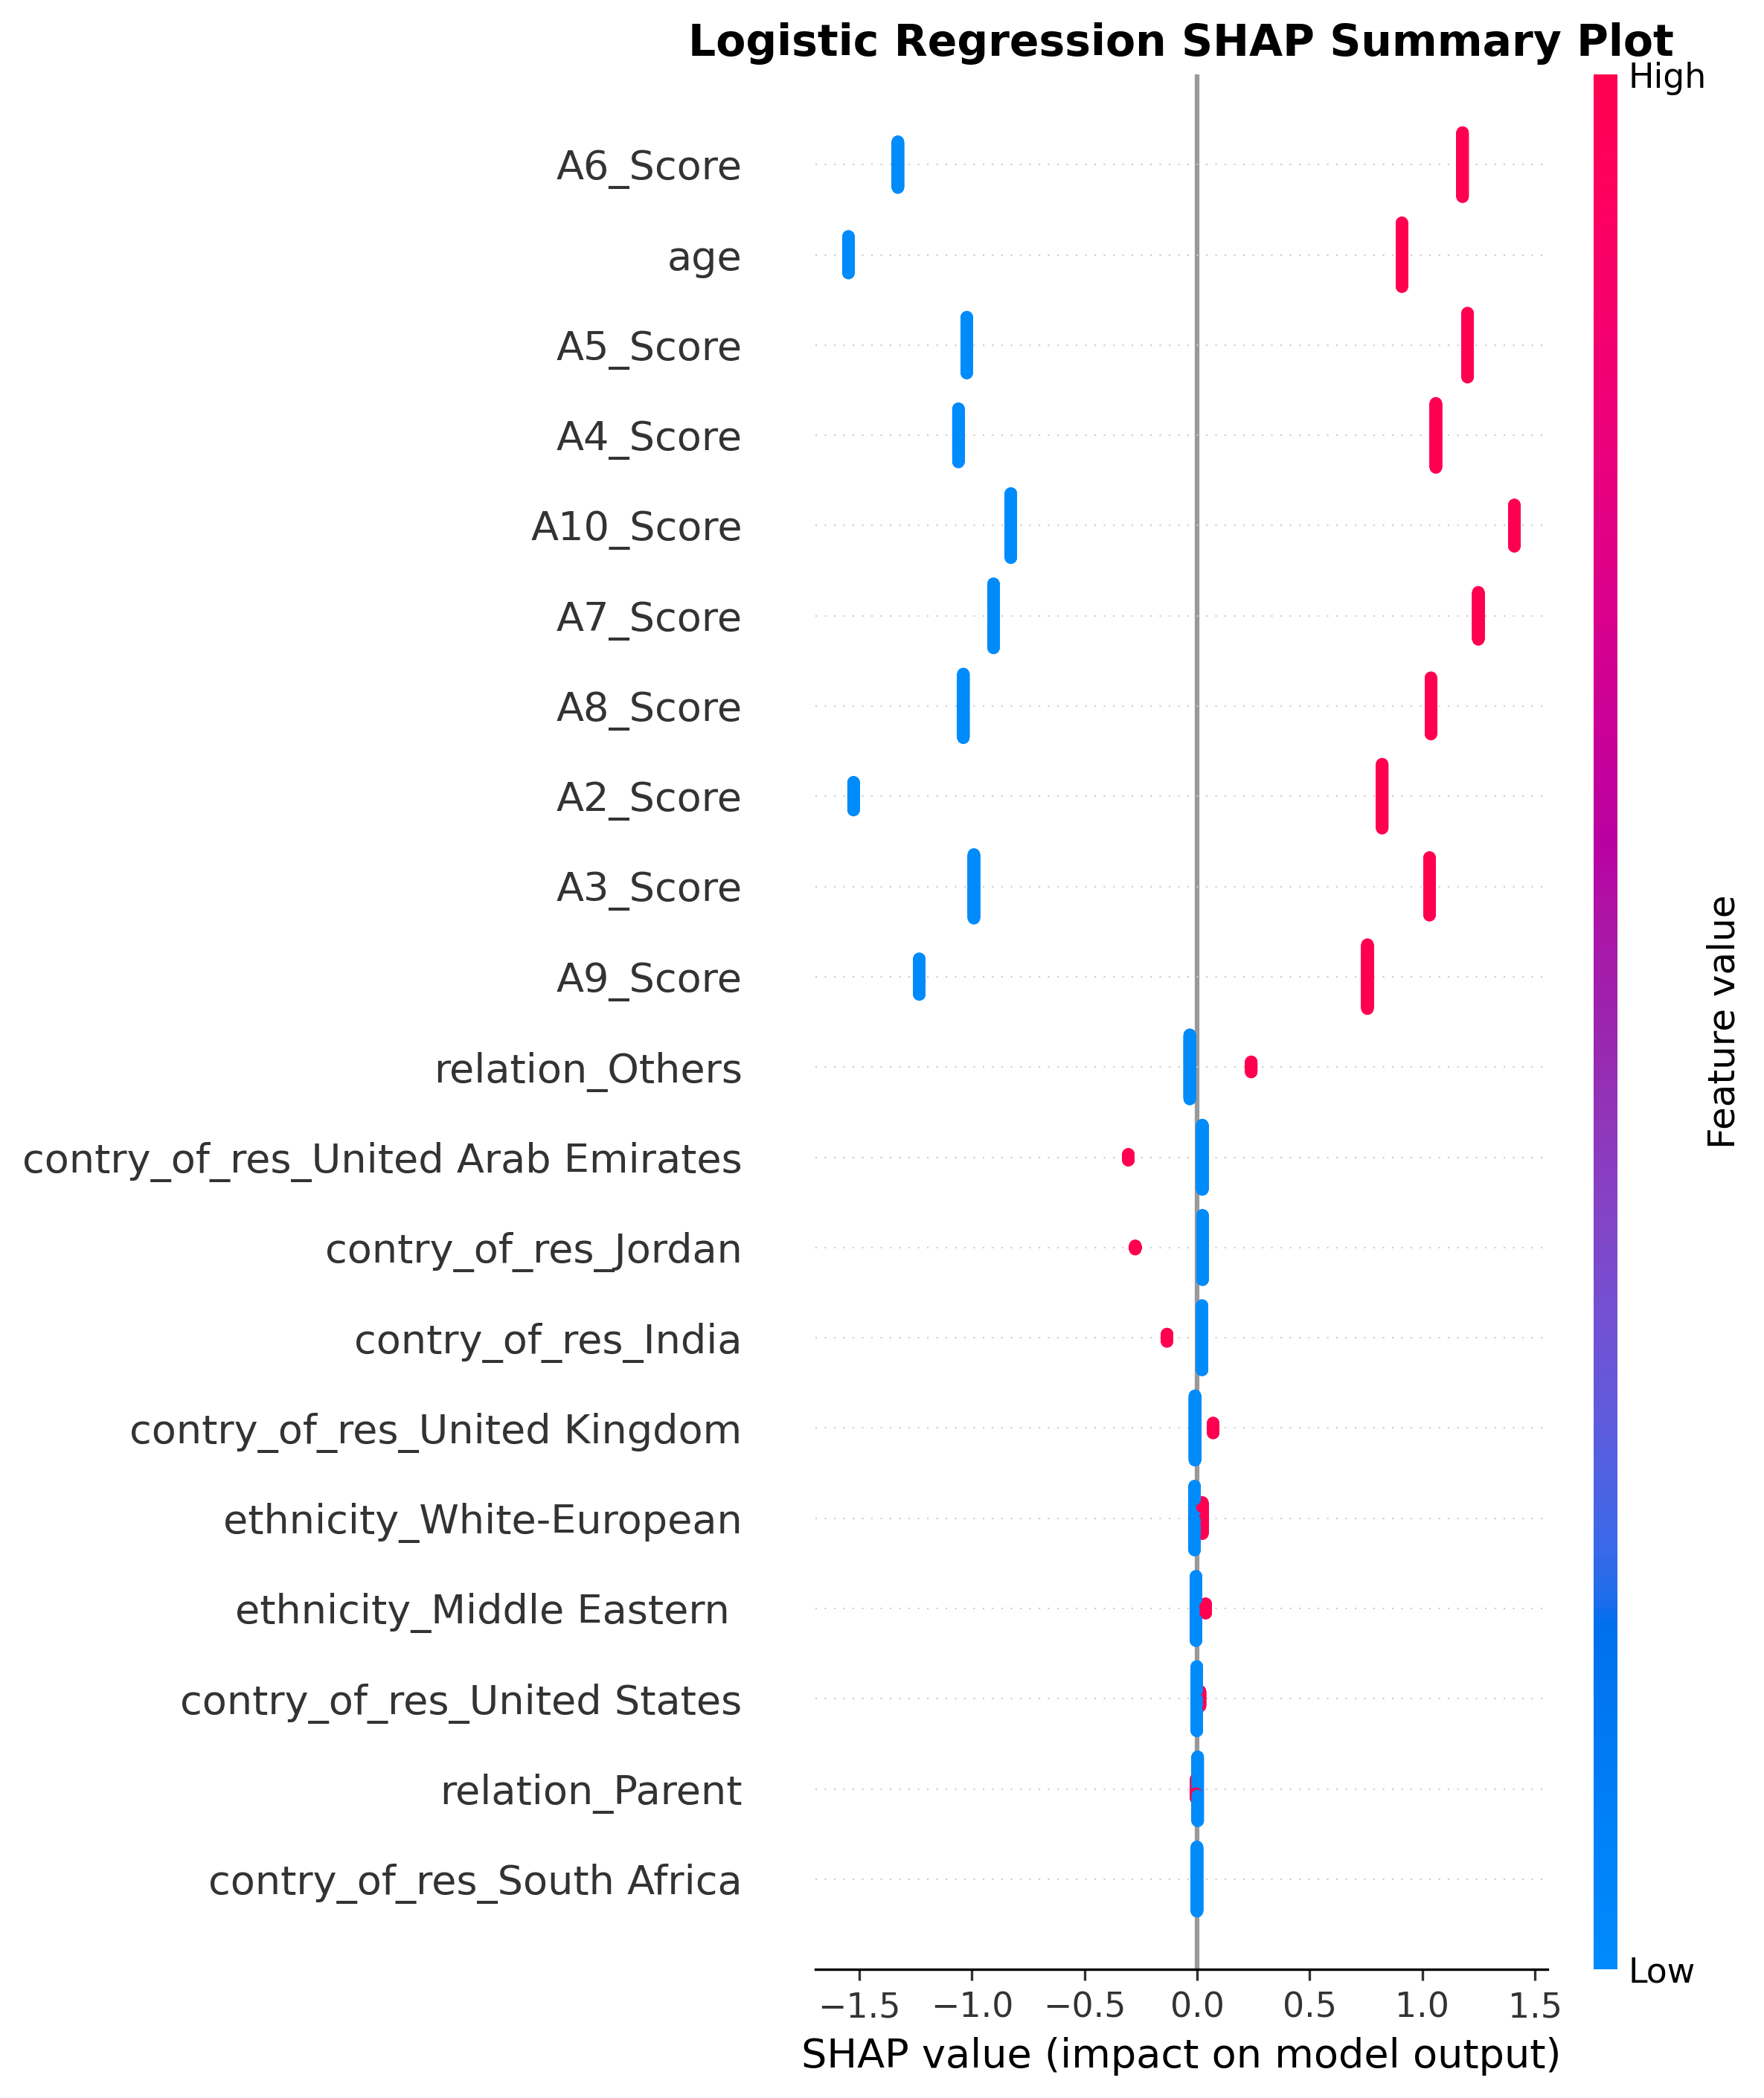

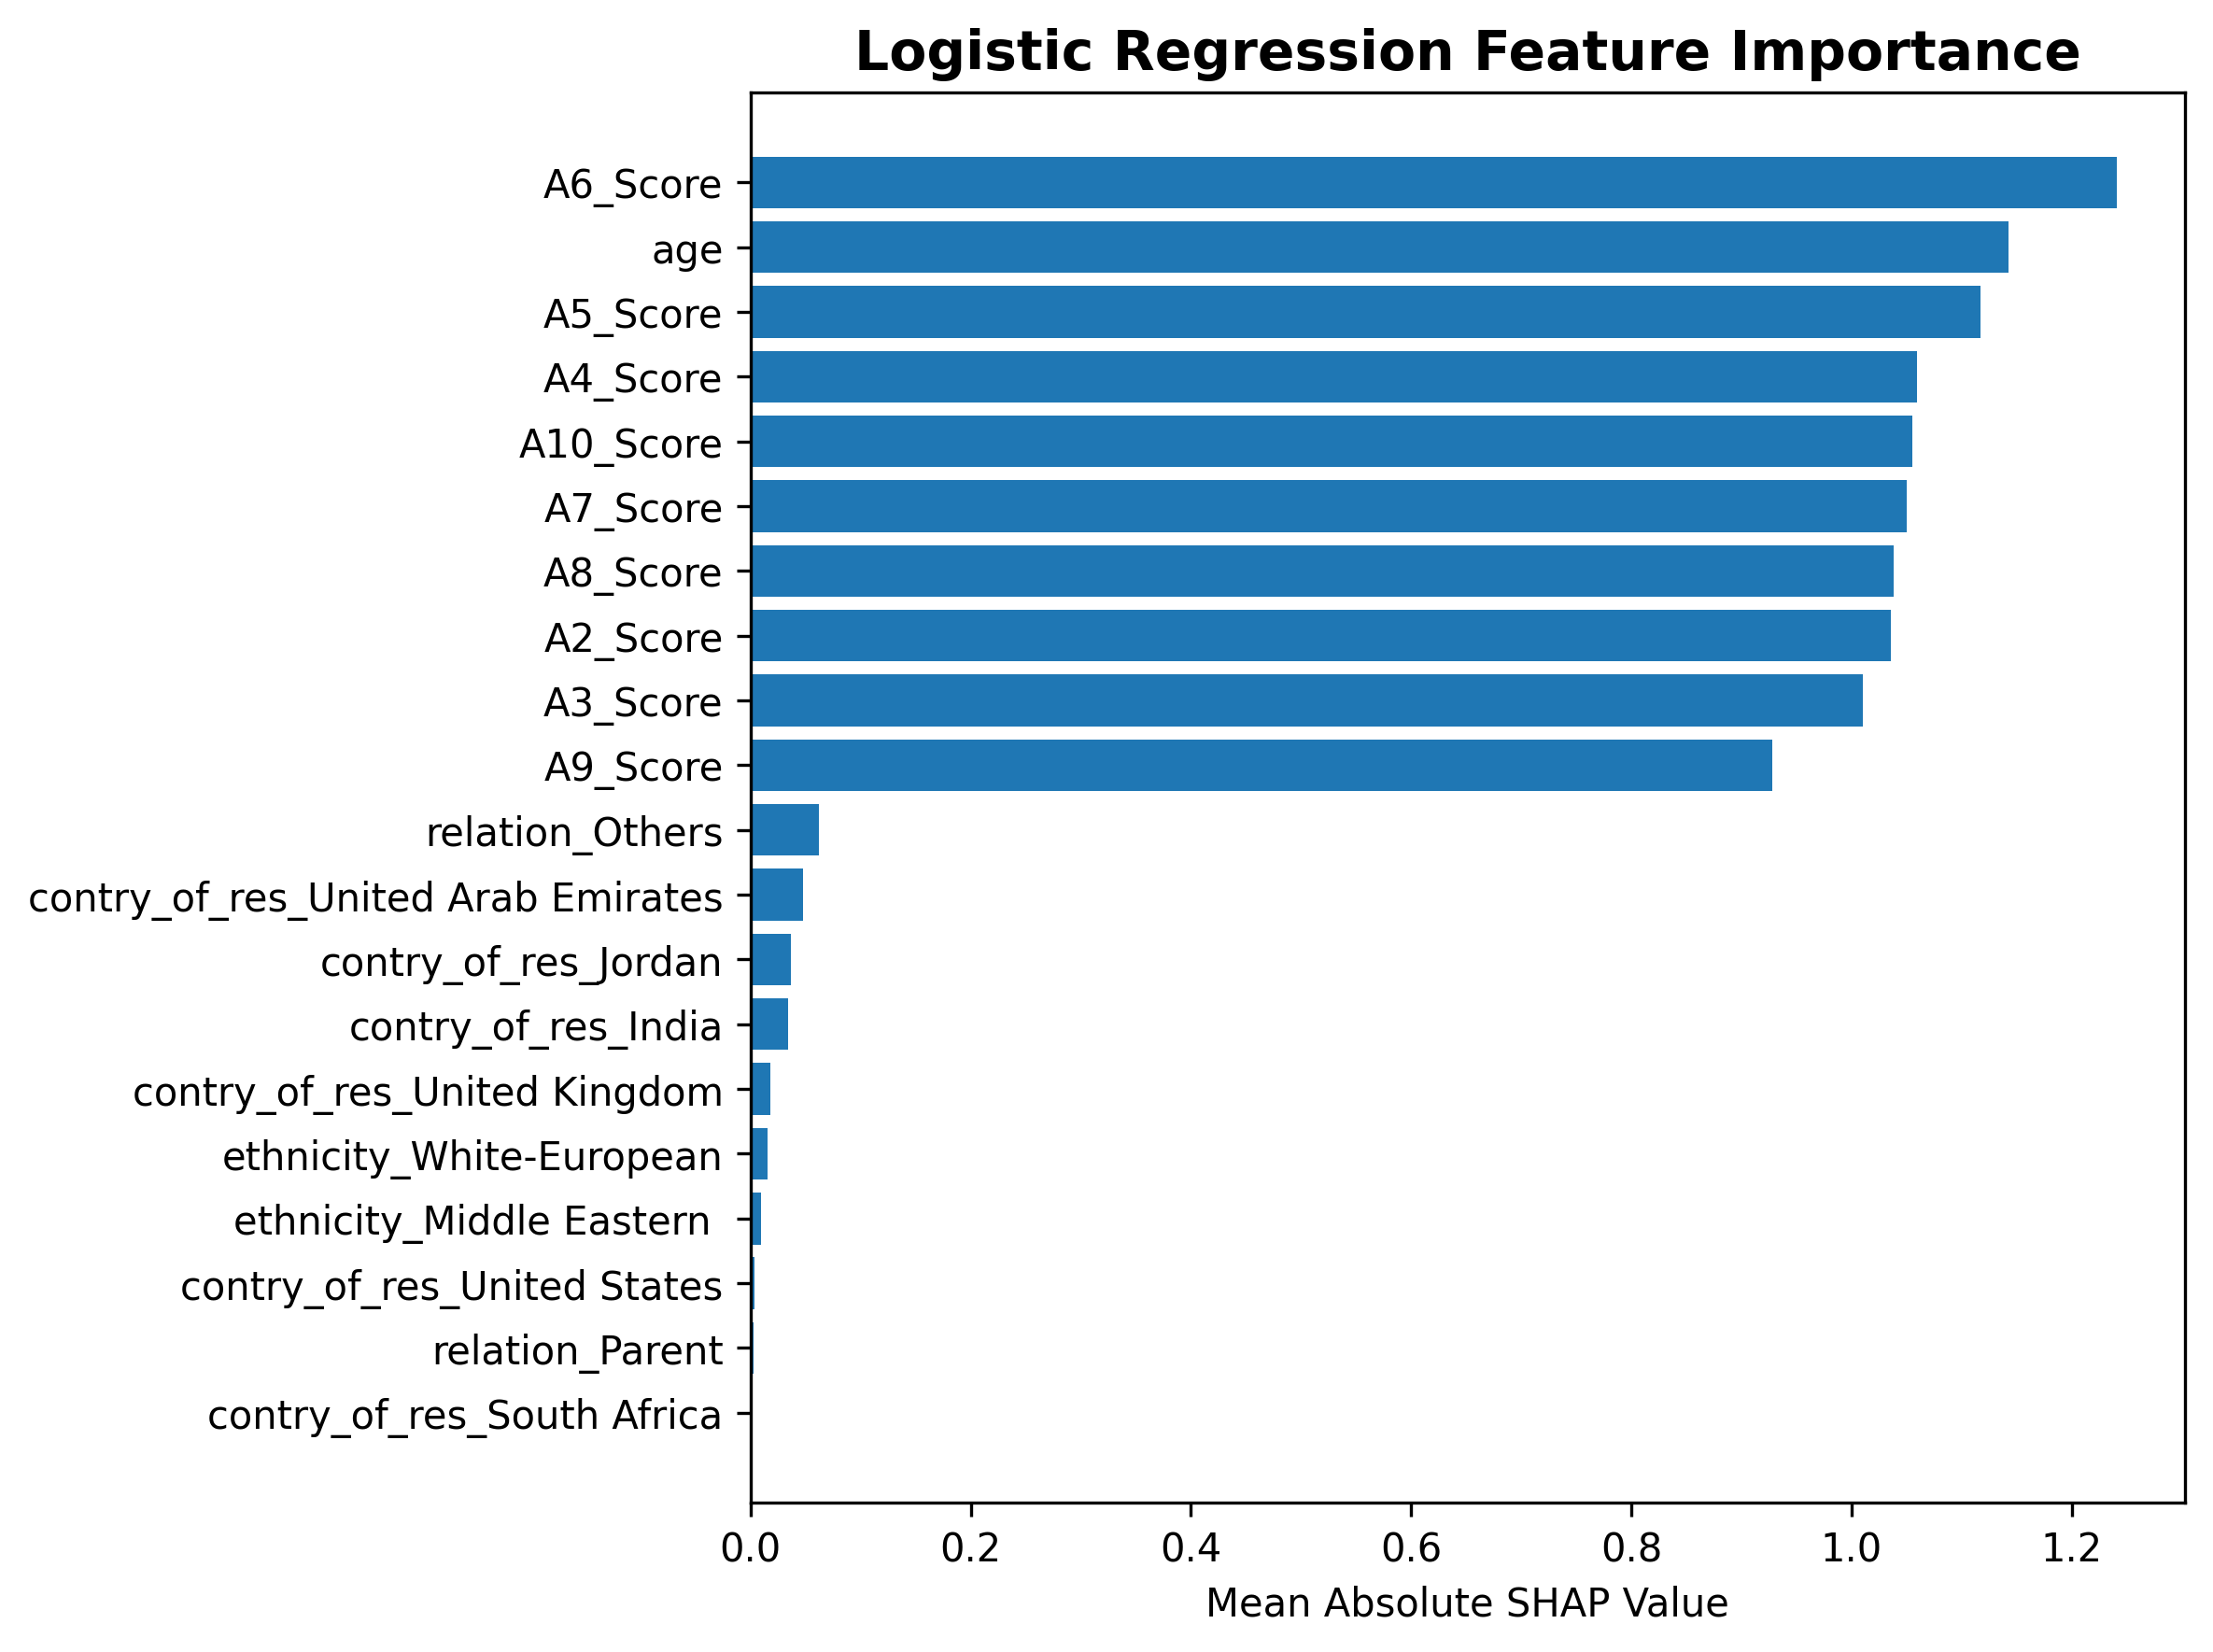

,Feature,Mean |SHAP|
4,A6_Score,1.240906
9,age,1.142837
3,A5_Score,1.117472
2,A4_Score,1.059711
8,A10_Score,1.055533
5,A7_Score,1.049881
6,A8_Score,1.037920
0,A2_Score,1.035939
1,A3_Score,1.010371
7,A9_Score,0.927816


Most Important Feature: A6_Score


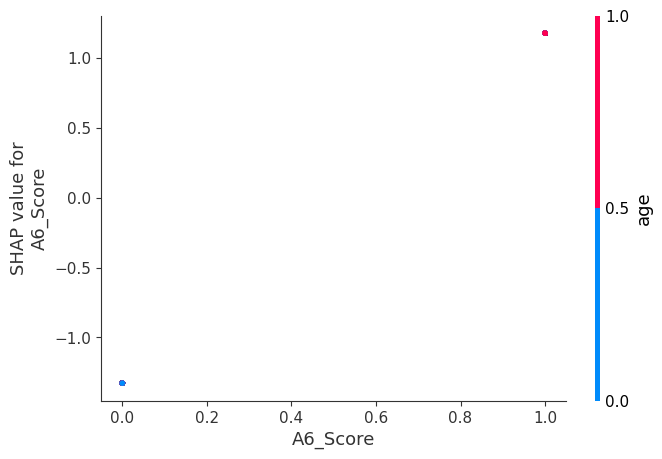

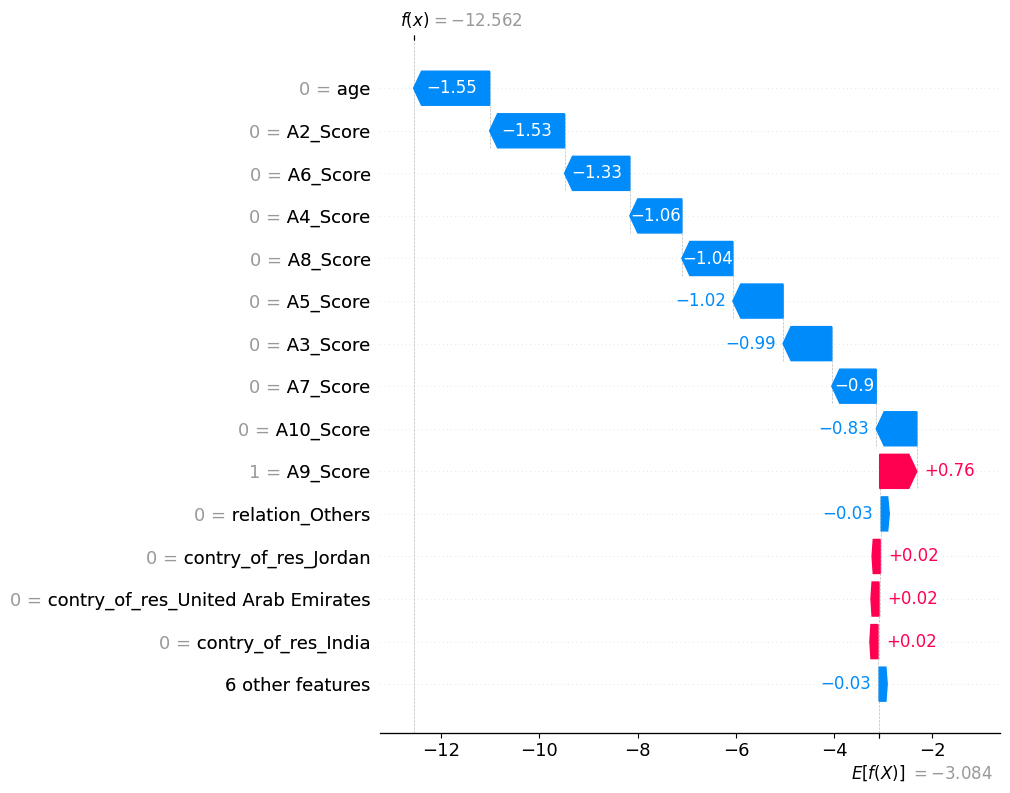

In [69]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# Logistic Regression SHAP Explainability
# =====================================================

# Load tuned Logistic Regression pipeline
lr_pipeline = tuned_models["Logistic Regression"]

# =====================================================
# Transform Data
# =====================================================

X_train_transformed = lr_pipeline[:-1].transform(X_train)
X_test_transformed = lr_pipeline[:-1].transform(X_test)

# =====================================================
# Get trained Logistic Regression model
# =====================================================

lr_model = lr_pipeline.named_steps["classifier"]

# =====================================================
# Selected Features
# =====================================================

selector = lr_pipeline.named_steps["selector"]

feature_names = X_train.columns[
    selector.get_support()
].tolist()

print("Selected Features:")
print(feature_names)

# =====================================================
# SHAP Linear Explainer
# =====================================================

explainer = shap.LinearExplainer(
    lr_model,
    X_train_transformed
)

shap_values = explainer(X_test_transformed)

print(type(shap_values))
print(shap_values.values.shape)

# =====================================================
# Handle Binary Classification
# =====================================================

if len(shap_values.values.shape) == 3:

    shap_values = shap.Explanation(
        values=shap_values.values[:, :, 1],
        base_values=shap_values.base_values[:, 1],
        data=shap_values.data,
        feature_names=feature_names
    )

else:

    shap_values = shap.Explanation(
        values=shap_values.values,
        base_values=shap_values.base_values,
        data=shap_values.data,
        feature_names=feature_names
    )

# =====================================================
# SHAP Summary Plot
# =====================================================

plt.figure(figsize=(10,6), dpi=300)

shap.summary_plot(
    shap_values,
    feature_names=feature_names,
    max_display=20,
    show=False
)

plt.title(
    "Logistic Regression SHAP Summary Plot",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("LR_SHAP_Summary.png", dpi=300)
plt.show()

# =====================================================
# SHAP Feature Importance
# =====================================================

importance = np.abs(shap_values.values).mean(axis=0)

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Mean |SHAP|": importance

})

importance_df = importance_df.sort_values(
    by="Mean |SHAP|",
    ascending=False
)

plt.figure(figsize=(8,6), dpi=300)

plt.barh(

    importance_df["Feature"][::-1],

    importance_df["Mean |SHAP|"][::-1]

)

plt.xlabel("Mean Absolute SHAP Value")

plt.title(
    "Logistic Regression Feature Importance",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("LR_SHAP_Bar.png", dpi=300)
plt.show()

# =====================================================
# Save Feature Importance
# =====================================================

importance_df.to_csv(
    "LR_SHAP_Feature_Importance.csv",
    index=False
)
lr_importance_df = importance_df.copy()

display(importance_df.head(20))

# =====================================================
# SHAP Dependence Plot
# =====================================================

best_feature = importance_df.iloc[0]["Feature"]

print("Most Important Feature:", best_feature)

shap.dependence_plot(

    best_feature,

    shap_values.values,

    X_test_transformed,

    feature_names=feature_names,

    interaction_index="auto"

)

# =====================================================
# SHAP Waterfall Plot
# =====================================================

sample_index = 0

shap.plots.waterfall(

    shap_values[sample_index],

    max_display=15

)

# svm

Selected Features:
['A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'ethnicity_Middle Eastern ', 'ethnicity_White-European', 'contry_of_res_India', 'contry_of_res_Jordan', 'contry_of_res_South Africa', 'contry_of_res_United Arab Emirates', 'contry_of_res_United Kingdom', 'contry_of_res_United States', 'relation_Others', 'relation_Parent']


  0%|          | 0/50 [00:00<?, ?it/s]

<class 'shap._explanation.Explanation'>
(50, 20, 2)


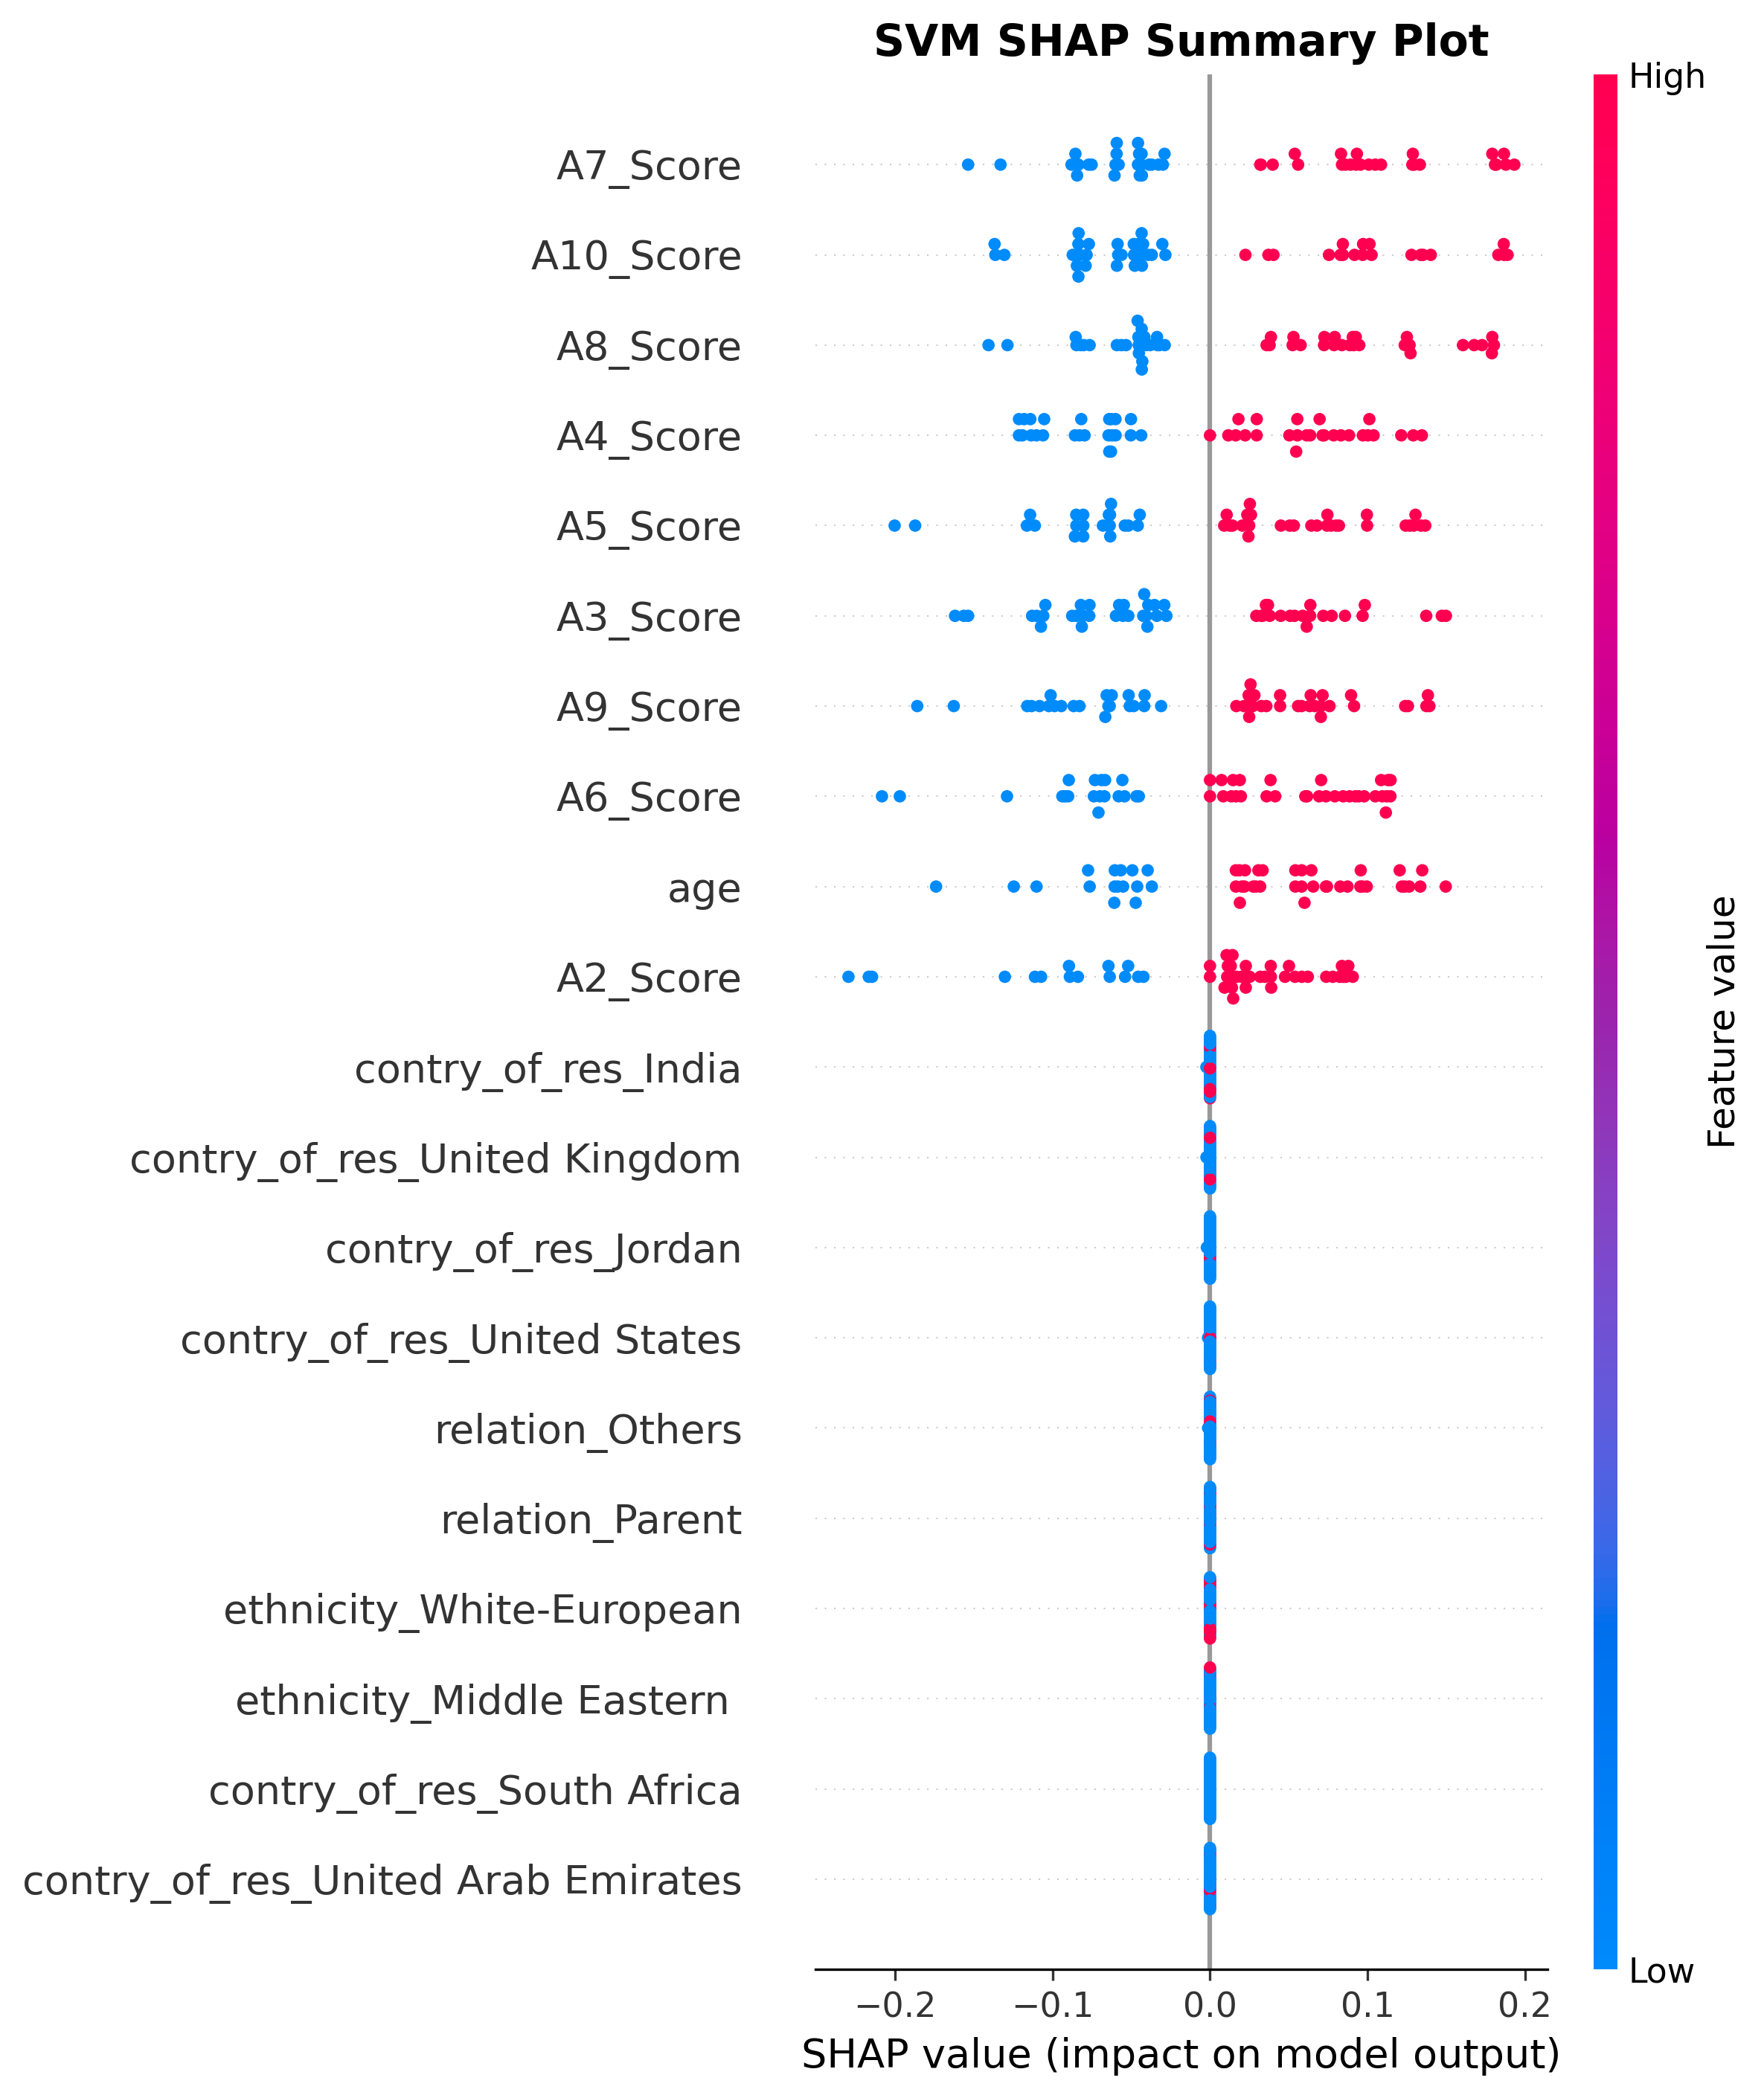

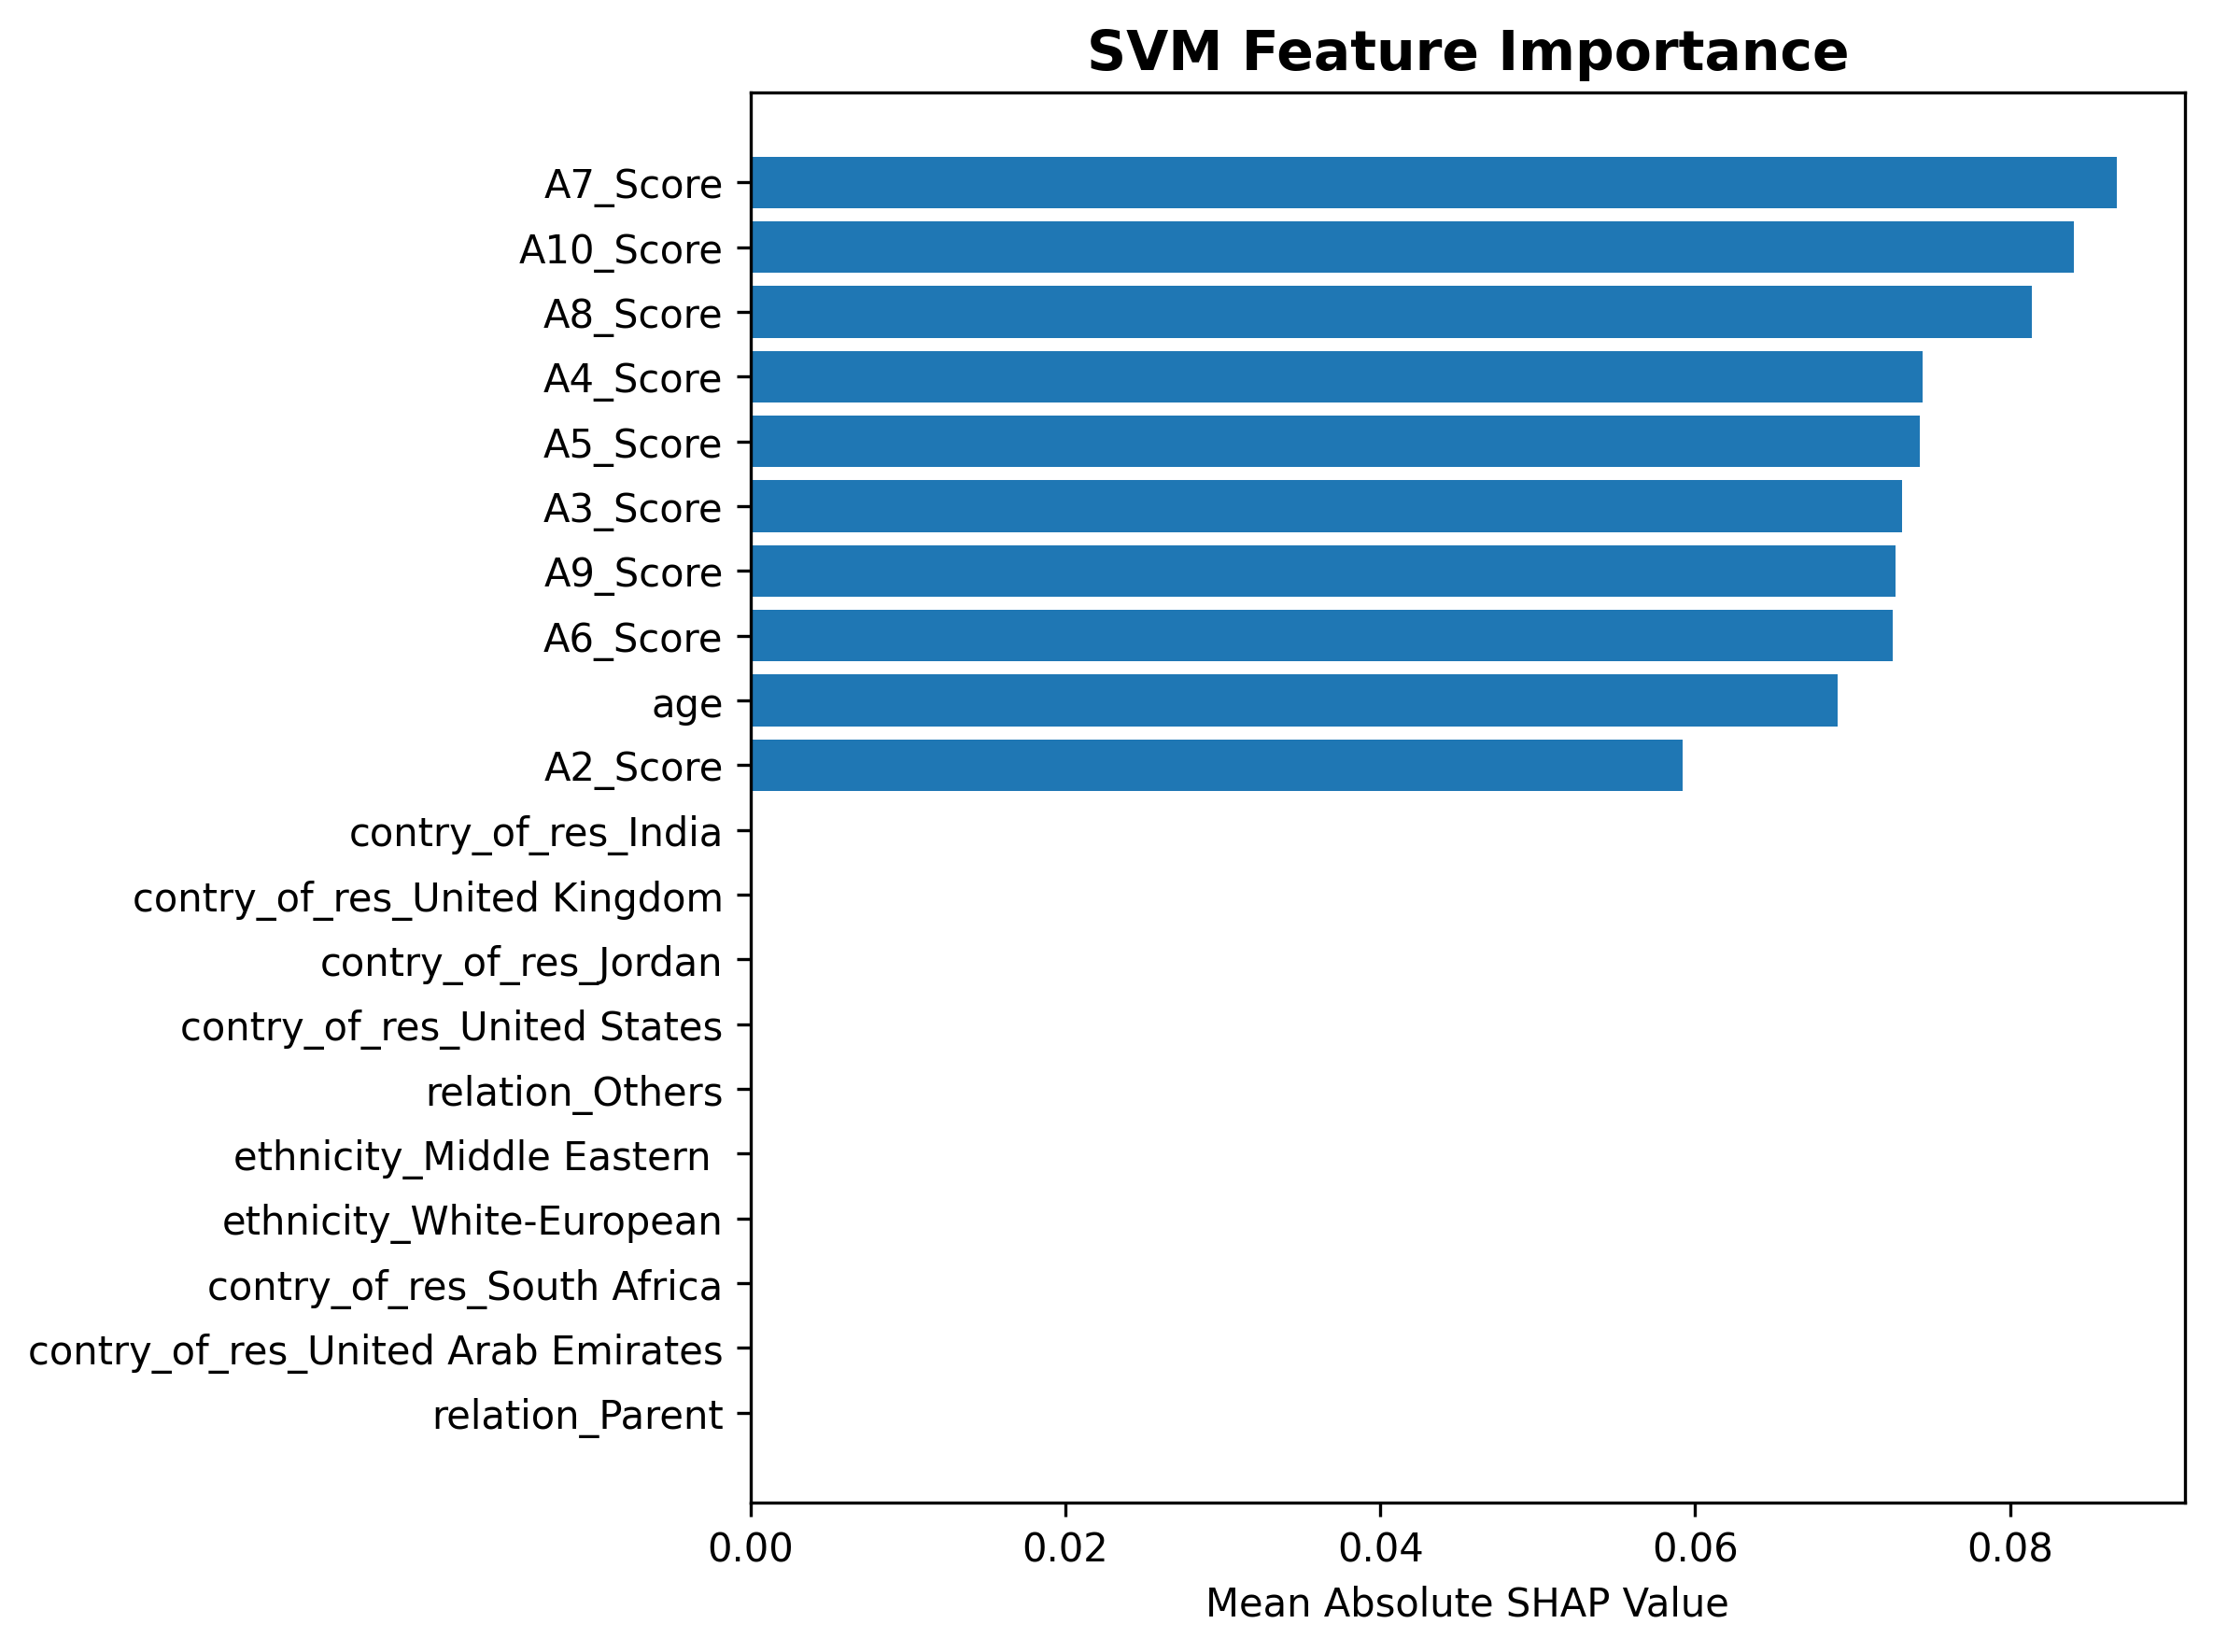

,Feature,Mean |SHAP|
5,A7_Score,0.086772
8,A10_Score,0.084042
6,A8_Score,0.081397
2,A4_Score,0.074466
3,A5_Score,0.074294
1,A3_Score,0.073165
7,A9_Score,0.072704
4,A6_Score,0.072531
9,age,0.069045
0,A2_Score,0.059210


Most Important Feature: A7_Score


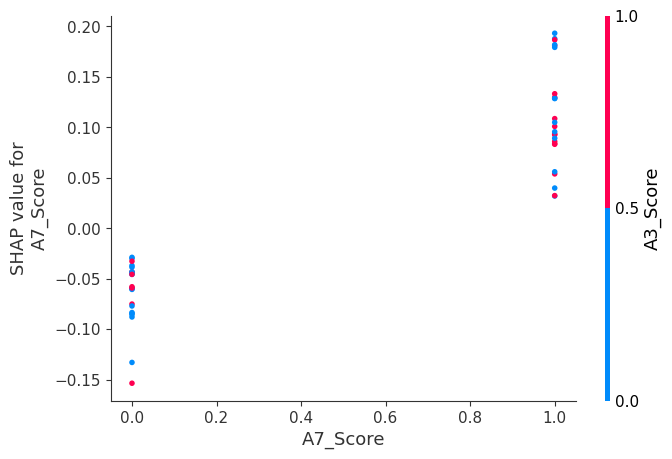

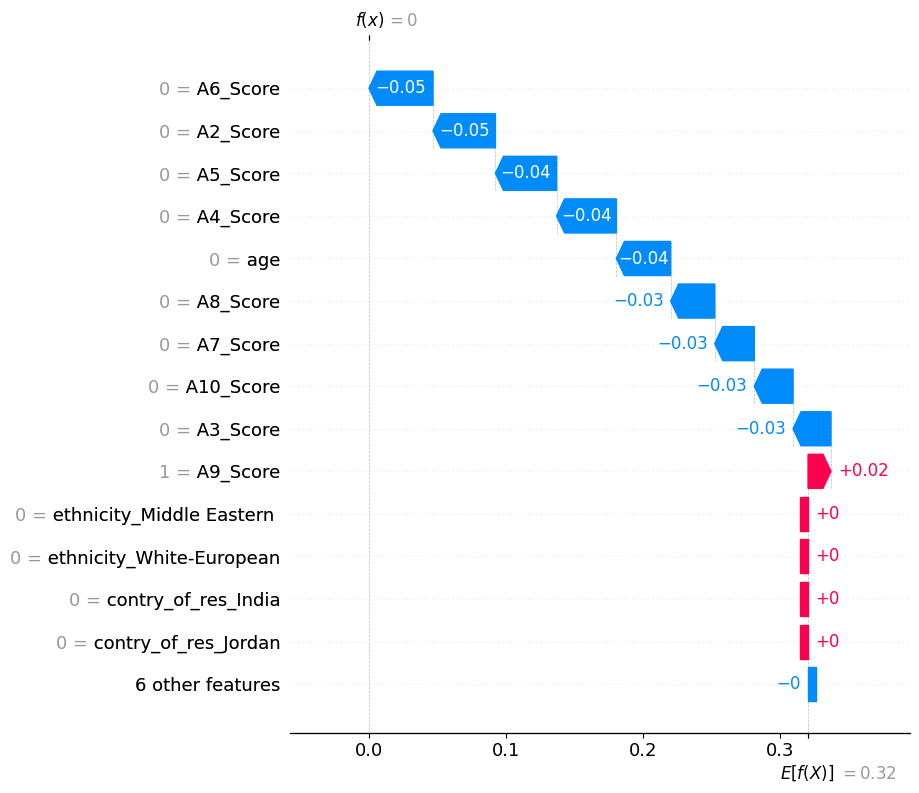

In [70]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# SVM SHAP Explainability
# =====================================================

# Load tuned SVM pipeline
svm_pipeline = tuned_models["SVM"]

# =====================================================
# Transform Data
# =====================================================

X_train_transformed = svm_pipeline[:-1].transform(X_train)
X_test_transformed = svm_pipeline[:-1].transform(X_test)

# =====================================================
# Get trained SVM model
# =====================================================

svm_model = svm_pipeline.named_steps["classifier"]

# =====================================================
# Selected Features
# =====================================================

selector = svm_pipeline.named_steps["selector"]

feature_names = X_train.columns[
    selector.get_support()
].tolist()

print("Selected Features:")
print(feature_names)

# =====================================================
# Background Samples
# =====================================================

background = shap.sample(
    X_train_transformed,
    50,
    random_state=42
)

# =====================================================
# Test Samples to Explain
# =====================================================

X_explain = X_test_transformed[:50]

# =====================================================
# Kernel Explainer
# =====================================================

explainer = shap.KernelExplainer(
    svm_model.predict_proba,
    background
)

# =====================================================
# Calculate SHAP Values
# =====================================================

shap_values = explainer(
    X_explain
)

print(type(shap_values))
print(shap_values.values.shape)

# =====================================================
# Handle Binary Classification
# =====================================================

if len(shap_values.values.shape) == 3:

    shap_values = shap.Explanation(

        values=shap_values.values[:, :, 1],

        base_values=shap_values.base_values[:, 1],

        data=shap_values.data,

        feature_names=feature_names

    )

else:

    shap_values = shap.Explanation(

        values=shap_values.values,

        base_values=shap_values.base_values,

        data=shap_values.data,

        feature_names=feature_names

    )

# =====================================================
# Summary Plot
# =====================================================

plt.figure(figsize=(10,6), dpi=300)

shap.summary_plot(
    shap_values,
    feature_names=feature_names,
    max_display=20,
    show=False
)

plt.title(
    "SVM SHAP Summary Plot",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "SVM_SHAP_Summary.png",
    dpi=300
)

plt.show()

# =====================================================
# SHAP Feature Importance
# =====================================================

importance = np.abs(
    shap_values.values
).mean(axis=0)

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Mean |SHAP|": importance

})

importance_df = importance_df.sort_values(
    by="Mean |SHAP|",
    ascending=False
)

plt.figure(figsize=(8,6), dpi=300)

plt.barh(

    importance_df["Feature"][::-1],

    importance_df["Mean |SHAP|"][::-1]

)

plt.xlabel("Mean Absolute SHAP Value")

plt.title(
    "SVM Feature Importance",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "SVM_SHAP_Bar.png",
    dpi=300
)

plt.show()

# =====================================================
# Save Feature Importance
# =====================================================

importance_df.to_csv(
    "SVM_SHAP_Feature_Importance.csv",
    index=False
)

svm_importance_df = importance_df.copy()
display(importance_df.head(20))

# =====================================================
# Dependence Plot
# =====================================================

best_feature = importance_df.iloc[0]["Feature"]

print("Most Important Feature:", best_feature)

shap.dependence_plot(

    best_feature,

    shap_values.values,

    X_explain,

    feature_names=feature_names,

    interaction_index="auto"

)

# =====================================================
# Waterfall Plot
# =====================================================

sample_index = 0

shap.plots.waterfall(

    shap_values[sample_index],

    max_display=15

)

# **comparison table**

In [71]:
comparison_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "XGBoost"
    ],

    "SHAP Method": [
        "LinearExplainer",
        "KernelExplainer",
        "TreeExplainer",
        "TreeExplainer"
    ],

    "Best Feature": [

        lr_importance_df.iloc[0]["Feature"],
        svm_importance_df.iloc[0]["Feature"],
        rf_importance_df.iloc[0]["Feature"],
        xgb_importance_df.iloc[0]["Feature"]

    ],

    "Mean |SHAP|": [

        lr_importance_df.iloc[0]["Mean |SHAP|"],
        svm_importance_df.iloc[0]["Mean |SHAP|"],
        rf_importance_df.iloc[0]["Mean |SHAP|"],
        xgb_importance_df.iloc[0]["Mean |SHAP|"]

    ]

})

comparison_df["Mean |SHAP|"] = comparison_df["Mean |SHAP|"].round(4)

comparison_df

,Model,SHAP Method,Best Feature,Mean |SHAP|
0,Logistic Regression,LinearExplainer,A6_Score,1.2409
1,SVM,KernelExplainer,A7_Score,0.0868
2,Random Forest,TreeExplainer,A10_Score,0.1029
3,XGBoost,TreeExplainer,A10_Score,1.6535
